# look at the general trends in SHAP scores across the 5'UTR and 3'UTR of all transcripts

In [1]:
import pickle
import os
import numpy as np
from matplotlib import pyplot as plt

try:
    os.chdir('scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    with open("output/importance/dev_shap.pkl", "rb") as f:
        importances_dev = pickle.load(f)
except:
    os.chdir('../../scripts')
    print(os.getcwd())
    from myShap import Explainer
    from myShap.ferret_extras import BaseExplainer, Explanation
    os.chdir('..')
    print(os.getcwd())
    with open("output/importance/dev_shap.pkl", "rb") as f:
        importances_dev = pickle.load(f)

with open("output/importance/train_shap.pkl", "rb") as f:
    importances_train = pickle.load(f)
with open("output/importance/test_shap.pkl", "rb") as f:
    importances_test = pickle.load(f)

importances = {
    "dev": importances_dev,
    "train": importances_train,
    "test": importances_test
}

/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay/scripts
/mnt/mr01-home01/m65338lb/projects/mRNA_LLM-worktrees/decay


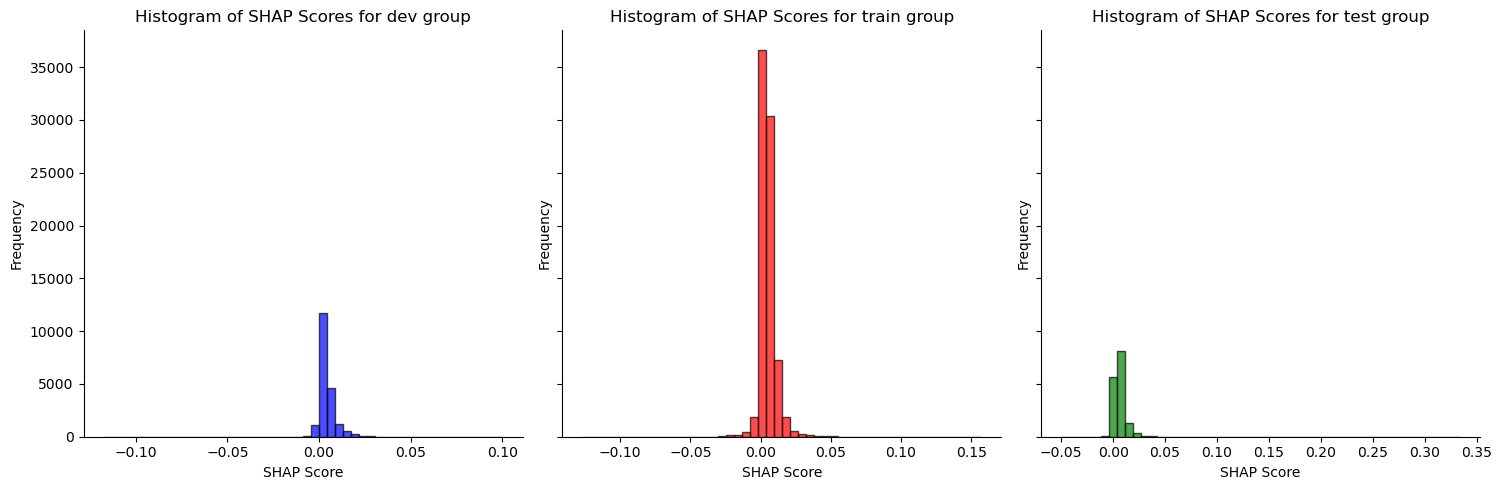

In [5]:
import numpy as np

import matplotlib.pyplot as plt

# Aggregate all SHAP scores for each group
all_scores = {}
for group in ['dev', 'train', 'test']:
    scores_list = []
    for imp in importances[group]:
        scores_list.extend(imp.scores.flatten())
    all_scores[group] = np.array(scores_list)

# Plot histograms for each group
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = {'dev': 'blue', 'train': 'red', 'test': 'green'}

for i, group in enumerate(['dev', 'train', 'test']):
    axes[i].hist(all_scores[group], bins=50, alpha=0.7, color=colors[group], edgecolor='black')
    axes[i].set_xlabel('SHAP Score')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Histogram of SHAP Scores for {group} group')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Mean SHAP score for train group: 0.0047
Standard Deviation of SHAP scores for train group: 0.0059
Number of values more extreme than +/- 1 SD: 11116
Number of values more extreme than +/- 2 SD: 3240
Number of values more extreme than +/- 3 SD: 1379


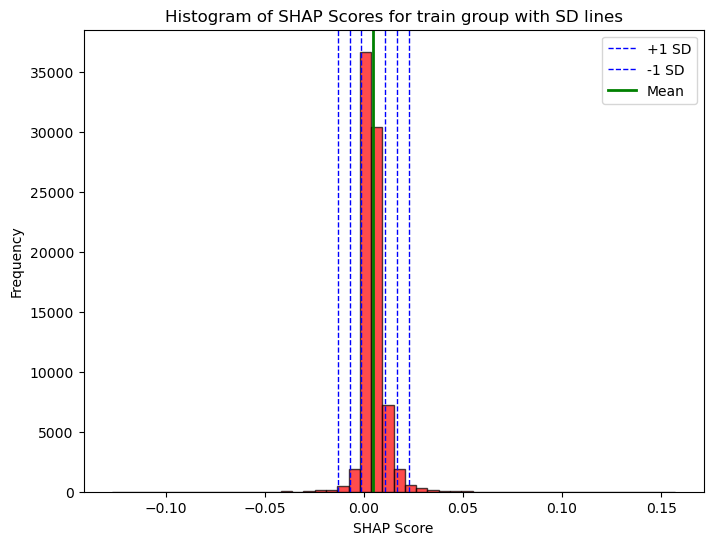

In [8]:
import numpy as np

import matplotlib.pyplot as plt

# Aggregate all SHAP scores for train group (already done in previous cells)
# all_scores['train'] is available

# Calculate mean and standard deviation
mean_train = np.mean(all_scores['train'])
std_train = np.std(all_scores['train'])

# Calculate counts of values more extreme than +/- 1, 2, 3 SD
count_1sd = np.sum((all_scores['train'] < mean_train - std_train) | (all_scores['train'] > mean_train + std_train))
count_2sd = np.sum((all_scores['train'] < mean_train - 2 * std_train) | (all_scores['train'] > mean_train + 2 * std_train))
count_3sd = np.sum((all_scores['train'] < mean_train - 3 * std_train) | (all_scores['train'] > mean_train + 3 * std_train))

print(f"Mean SHAP score for train group: {mean_train:.4f}")
print(f"Standard Deviation of SHAP scores for train group: {std_train:.4f}")
print(f"Number of values more extreme than +/- 1 SD: {count_1sd}")
print(f"Number of values more extreme than +/- 2 SD: {count_2sd}")
print(f"Number of values more extreme than +/- 3 SD: {count_3sd}")

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(all_scores['train'], bins=50, alpha=0.7, color='red', edgecolor='black')
plt.xlabel('SHAP Score')
plt.ylabel('Frequency')
plt.title('Histogram of SHAP Scores for train group with SD lines')

# Add vertical lines for +/- 1, 2, 3 standard deviations
for i in range(1, 4):
    plt.axvline(mean_train + i * std_train, color='blue', linestyle='--', linewidth=1, label=f'+{i} SD' if i == 1 else None)
    plt.axvline(mean_train - i * std_train, color='blue', linestyle='--', linewidth=1, label=f'-{i} SD' if i == 1 else None)

# Add mean line
plt.axvline(mean_train, color='green', linestyle='-', linewidth=2, label='Mean')

plt.legend()
plt.show()

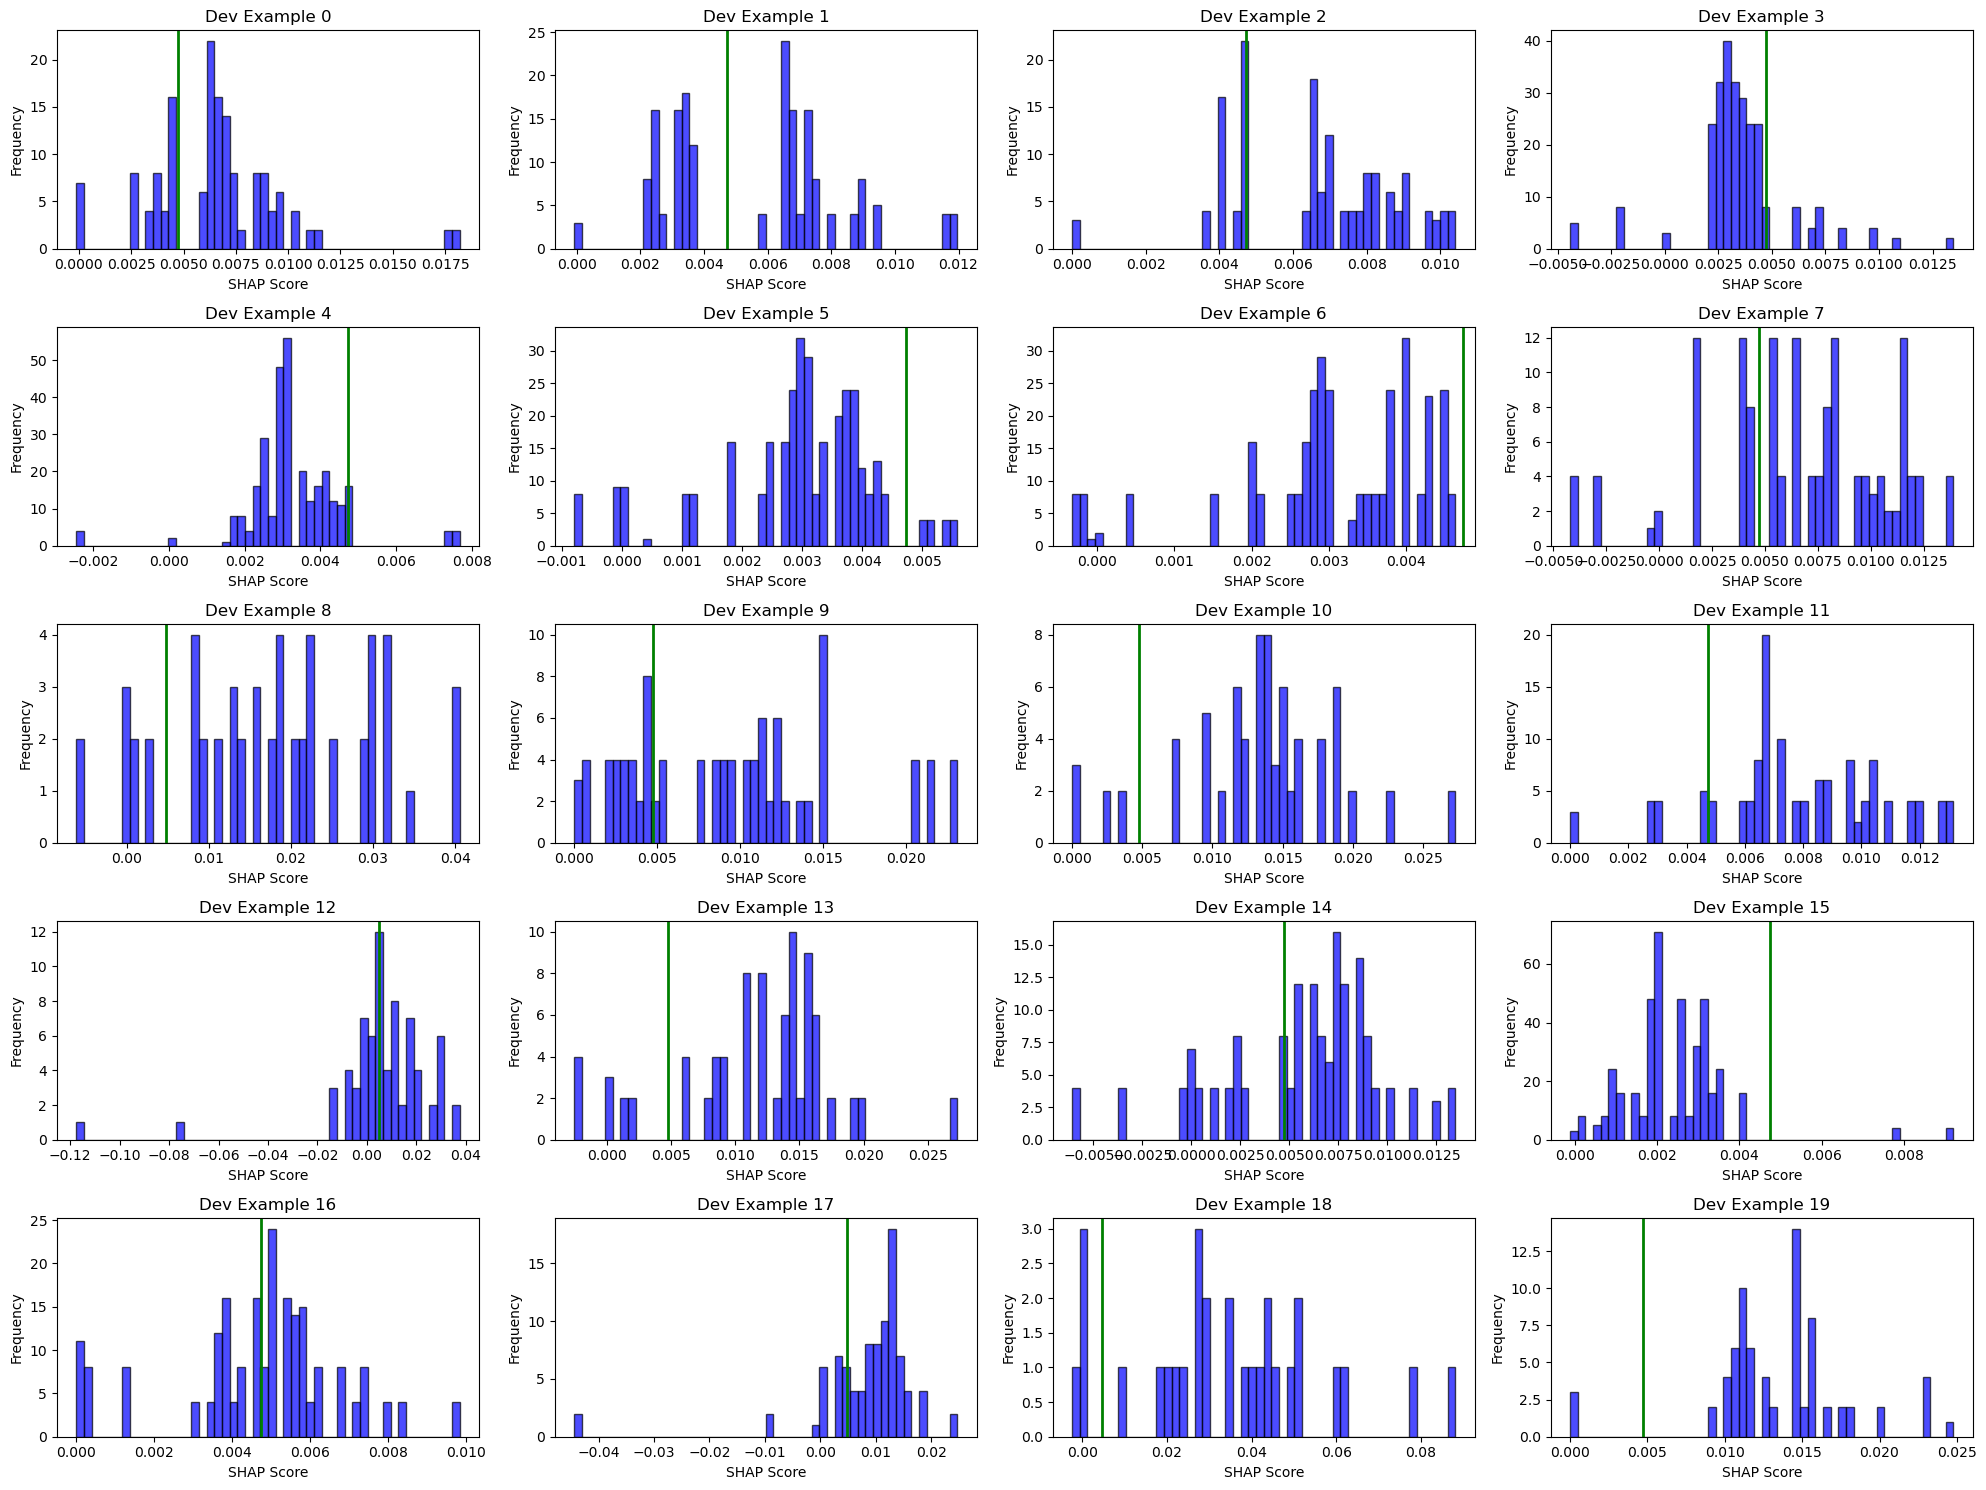

In [12]:
import matplotlib.pyplot as plt

# Plot a 5x4 grid of histograms for the first 20 dev examples
fig, axes = plt.subplots(5, 4, figsize=(20, 15), sharex=False, sharey=False)
axes = axes.flatten()

for i in range(20):
    scores = importances['dev'][i].scores.flatten()
    axes[i].hist(scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[i].axvline(mean_train, color='green', linestyle='-', linewidth=2, label='Mean Train SHAP Score')
    axes[i].set_title(f'Dev Example {i}')
    axes[i].set_xlabel('SHAP Score')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

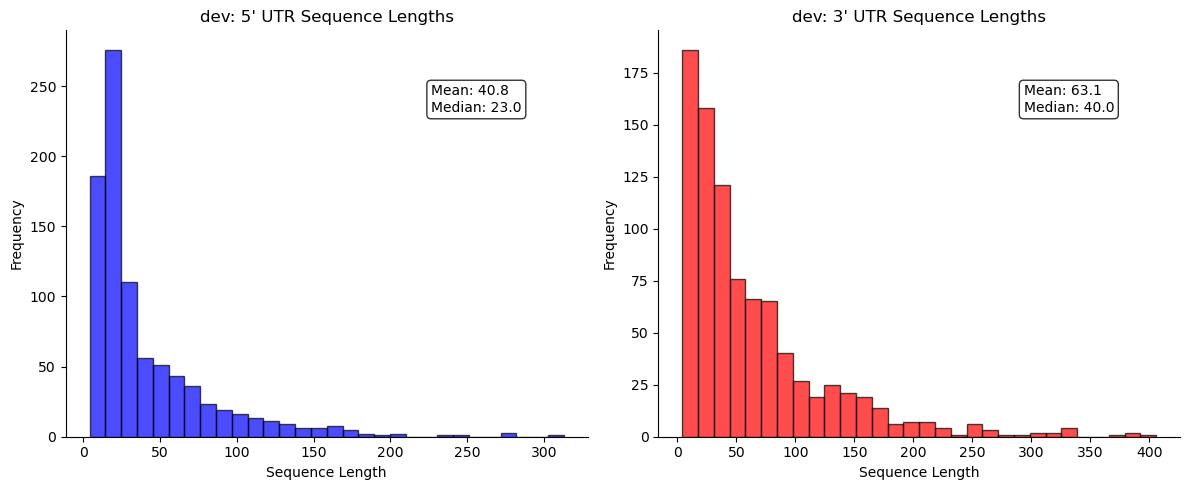

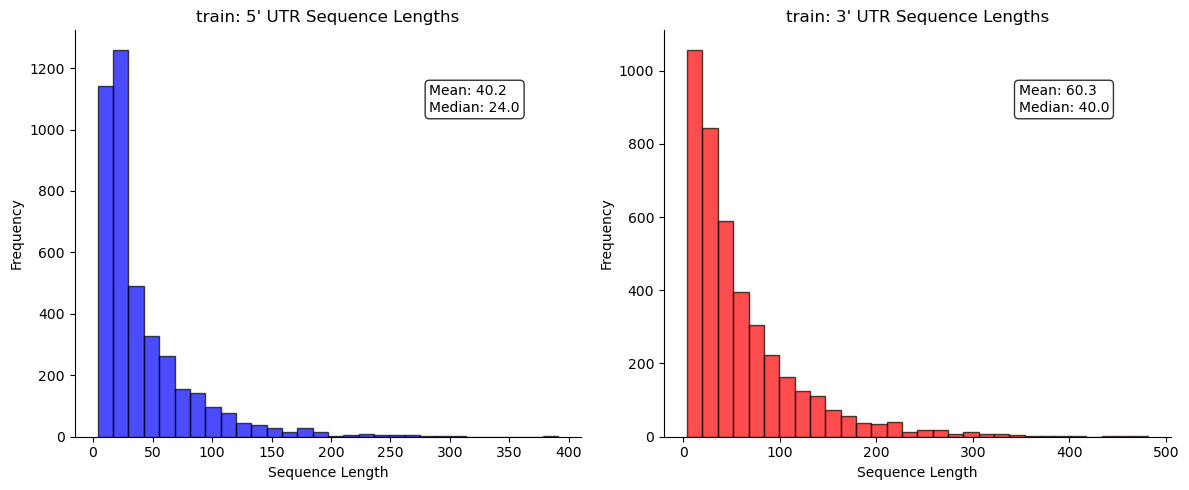

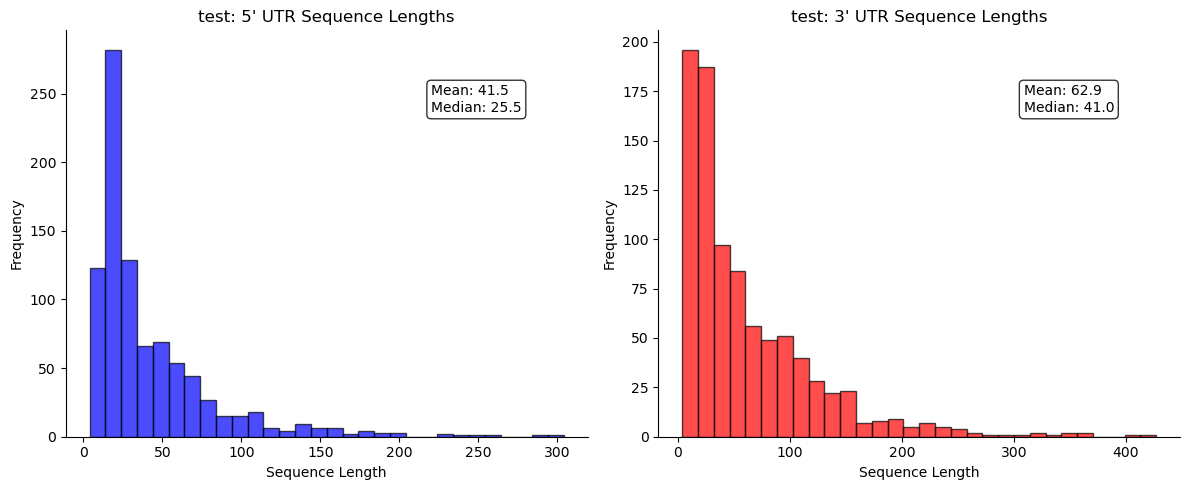

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Example: variable-length sequences
#sequences = [
#    np.array([1, 3, 2, 5, 7]),
#    np.array([2, 4, 6]),
#    np.array([1, 2, 3, 4, 6, 8, 10]),
#    np.array([3, 3.5, 4, 4.5, 5])
#]
seqs5 = {'dev':[], 'train':[], 'test':[]}
seqs3 = {'dev':[], 'train':[], 'test':[]}
for group in ['dev','train','test']:
    for imp in importances[group]:
        tmp5 = imp.scores[1:imp.tokens.index('[SEP]')].flatten()*len(imp.scores)
        tmp3 = imp.scores[imp.tokens.index('[SEP]')+1:-1].flatten()*len(imp.scores)
        if len(tmp5) <= 3 or len(tmp3) <= 3:
            continue
        seqs5[group].append(tmp5)
        seqs3[group].append(tmp3)

    # Calculate lengths of sequences
    lengths_5 = [len(seq) for seq in seqs5[group]]
    lengths_3 = [len(seq) for seq in seqs3[group]]

    # Create histograms
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # 5' UTR length histogram
    ax1.hist(lengths_5, bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax1.set_xlabel('Sequence Length')
    ax1.set_ylabel('Frequency')
    ax1.set_title(f"{group}: 5' UTR Sequence Lengths")
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Add statistics text
    mean_5 = np.mean(lengths_5)
    median_5 = np.median(lengths_5)
    ax1.text(0.7, 0.8, f'Mean: {mean_5:.1f}\nMedian: {median_5:.1f}', 
             transform=ax1.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 3' UTR length histogram
    ax2.hist(lengths_3, bins=30, alpha=0.7, color='red', edgecolor='black')
    ax2.set_xlabel('Sequence Length')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f"{group}: 3' UTR Sequence Lengths")
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Add statistics text
    mean_3 = np.mean(lengths_3)
    median_3 = np.median(lengths_3)
    ax2.text(0.7, 0.8, f'Mean: {mean_3:.1f}\nMedian: {median_3:.1f}', 
             transform=ax2.transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    #plt.savefig('figures/UTR_sequence_length_histograms.svg')
    plt.show()


<Figure size 1200x800 with 0 Axes>

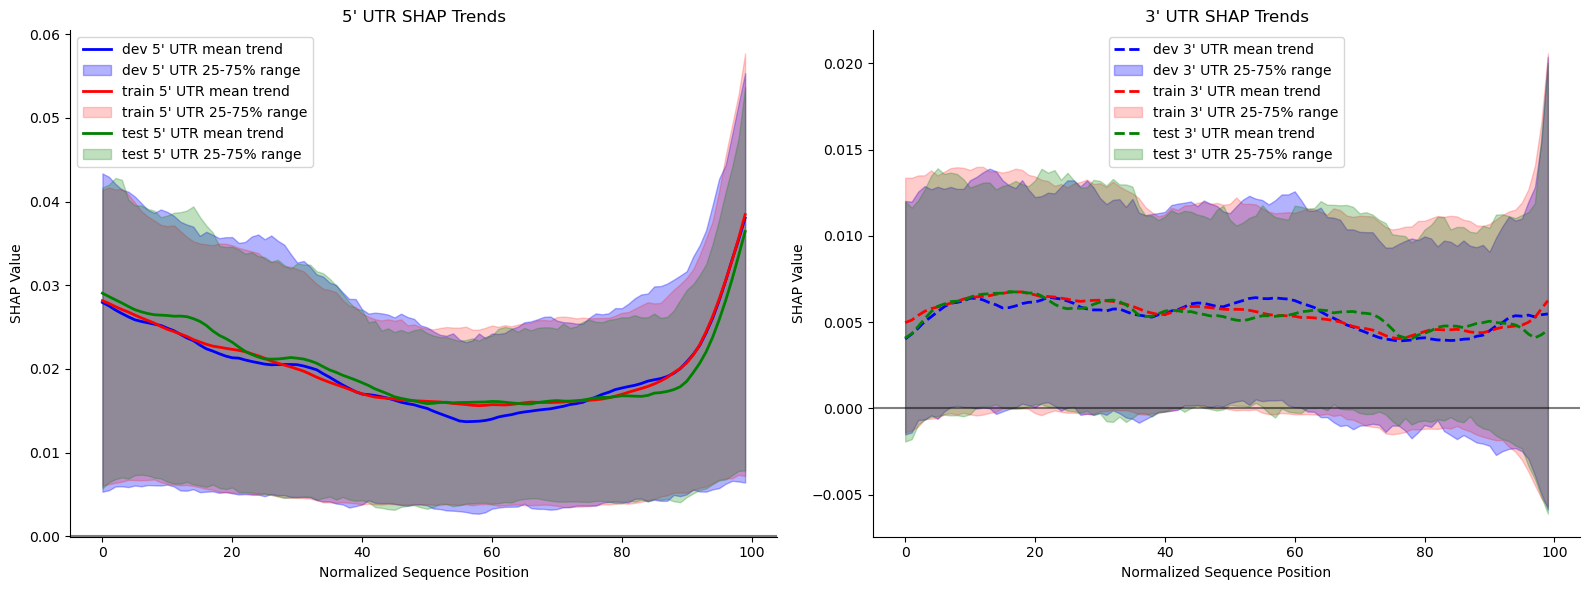

In [99]:
# Truncate sequences to reasonable lengths first
for group in ['dev', 'train', 'test']:
    seqs5[group] = [tmp5[-(min(len(tmp5),100)):] for tmp5 in seqs5[group]]
    seqs3[group] = [tmp3[-(min(len(tmp3),150)):] for tmp3 in seqs3[group]]

# Target length for interpolation
target_len = 100

# Create a single figure for all groups and UTR types
plt.figure(figsize=(12, 8))

# Create subplots - 2 columns for 5'UTR and 3'UTR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = {'dev': 'blue', 'train': 'red', 'test': 'green'}
alphas = {'dev': 0.3, 'train': 0.2, 'test': 0.25}

for group in ['dev', 'train', 'test']:
    color = colors[group]
    alpha = alphas[group]
    
    # Plot 5' UTR on left subplot
    sequences = seqs5[group]
    resampled = []
    for seq in sequences:
        x_old = np.linspace(0, 1, len(seq))
        x_new = np.linspace(0, 1, target_len)
        f = interp1d(x_old, seq, kind="linear")
        seq_new = f(x_new)
        resampled.append(seq_new)
    
    resampled = np.vstack(resampled)
    mean_trend = np.mean(resampled, axis=0)
    p25 = np.percentile(resampled, 25, axis=0)
    p75 = np.percentile(resampled, 75, axis=0)
    
    ax1.plot(mean_trend, color=color, linewidth=2, linestyle='-', 
            label=f"{group} 5' UTR mean trend")
    ax1.fill_between(range(target_len), p25, p75, color=color, alpha=alpha, 
                    label=f"{group} 5' UTR 25-75% range")
    
    # Plot 3' UTR on right subplot
    sequences = seqs3[group]
    resampled = []
    for seq in sequences:
        x_old = np.linspace(0, 1, len(seq))
        x_new = np.linspace(0, 1, target_len)
        f = interp1d(x_old, seq, kind="linear")
        seq_new = f(x_new)
        resampled.append(seq_new)
    
    resampled = np.vstack(resampled)
    mean_trend = np.mean(resampled, axis=0)
    p25 = np.percentile(resampled, 25, axis=0)
    p75 = np.percentile(resampled, 75, axis=0)
    
    ax2.plot(mean_trend, color=color, linewidth=2, linestyle='--', 
            label=f"{group} 3' UTR mean trend")
    ax2.fill_between(range(target_len), p25, p75, color=color, alpha=alpha, 
                    label=f"{group} 3' UTR 25-75% range")

# Configure left subplot (5' UTR)
ax1.set_title("5' UTR SHAP Trends")
ax1.set_xlabel("Normalized Sequence Position")
ax1.set_ylabel("SHAP Value")
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend()

# Configure right subplot (3' UTR)
ax2.set_title("3' UTR SHAP Trends")
ax2.set_xlabel("Normalized Sequence Position")
ax2.set_ylabel("SHAP Value")
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend()

plt.tight_layout()
#plt.savefig('figures/SHAP_trends_all_groups_UTR_comparison.svg', bbox_inches='tight')
plt.show()


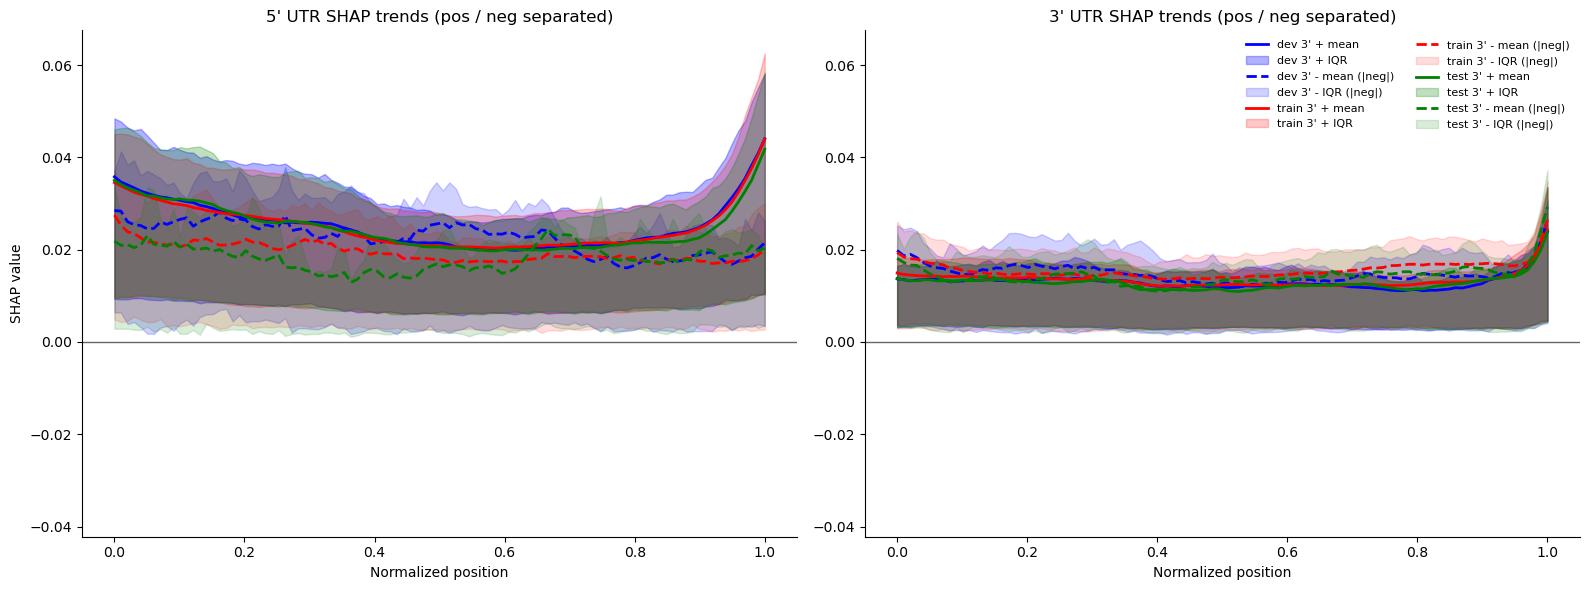

In [ ]:




#### TO DO ####
# - bin the sequences by length and run the interpolation and comparison on those bins, maybe long vs short sequences behave differently
# - This this interpolation approach to work with the split neg and post SHAP values. 






# Split positive / negative SHAP, interpolate to common length, and plot all groups together
# Truncate (same rule as before)
for group in ['dev', 'train', 'test']:
    seqs5[group] = [s[-min(len(s), 100):] for s in seqs5[group]]
    seqs3[group] = [s[-min(len(s), 150):] for s in seqs3[group]]

target_len = 100  # interpolation length for both UTR types (adjust if you want different)

colors = {'dev': 'blue', 'train': 'red', 'test': 'green'}
alphas = {'dev': 0.30, 'train': 0.22, 'test': 0.25}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

def aggregate_pos_neg(sequences, tgt_len):
    """
    Interpolate sequences to tgt_len and return (pos_stats, neg_stats)
    Each stats dict has mean, p25, p75, x
    Negative stats computed on absolute magnitudes then plotted as negative.
    """
    pos_list = []
    neg_list = []
    x_new = np.linspace(0, 1, tgt_len)
    for seq in sequences:
        x_old = np.linspace(0, 1, len(seq))
        if len(seq) < 2:
            continue
        f = interp1d(x_old, seq, kind="linear")
        seq_new = f(x_new)
        pos_list.append(np.where(seq_new > 0, seq_new, np.nan))
        neg_part = np.where(seq_new < 0, -seq_new, np.nan)  # store magnitudes
        neg_list.append(neg_part)

    def stats(stack):
        if len(stack) == 0:
            return dict(mean=None, p25=None, p75=None)
        arr = np.vstack(stack)
        with np.errstate(all='ignore'):
            mean = np.nanmean(arr, axis=0)
            p25 = np.nanpercentile(arr, 25, axis=0)
            p75 = np.nanpercentile(arr, 75, axis=0)
        return dict(mean=mean, p25=p25, p75=p75)

    return stats(pos_list), stats(neg_list), x_new

# Collect global y-range to synchronize axes
y_min, y_max = np.inf, -np.inf
cache = {}

for utr, seqs_dict, ax in [("5'", seqs5, ax1), ("3'", seqs3, ax2)]:
    for group in ['dev', 'train', 'test']:
        pos_stats, neg_stats, x_new = aggregate_pos_neg(seqs_dict[group], target_len)
        cache[(utr, group)] = (pos_stats, neg_stats, x_new)
        for st in (pos_stats, neg_stats):
            if st['mean'] is not None:
                if utr == "5'":
                    y_min = min(y_min, np.nanmin(st['p25']))
                    y_max = max(y_max, np.nanmax(st['p75']))
                else:
                    y_min = min(y_min, -np.nanmax(st['p75']), np.nanmin(st['p25']))
                    y_max = max(y_max, np.nanmax(st['p75']), -np.nanmin(st['p25']))

# Plot
for utr, ax in [("5'", ax1), ("3'", ax2)]:
    for group in ['dev', 'train', 'test']:
        pos_stats, neg_stats, x_new = cache[(utr, group)]
        color = colors[group]
        alpha = alphas[group]

        # Positive
        if pos_stats['mean'] is not None:
            ax.plot(x_new, pos_stats['mean'], color=color, lw=2,
                    label=f"{group} {utr} + mean")
            ax.fill_between(x_new, pos_stats['p25'], pos_stats['p75'],
                            color=color, alpha=alpha, label=f"{group} {utr} + IQR")

            # Negative (plot magnitudes on positive axis for direct comparison)
            if neg_stats['mean'] is not None:
                ax.plot(x_new, neg_stats['mean'], color=color, lw=2, ls='--',
                        label=f"{group} {utr} - mean (|neg|)")
                ax.fill_between(x_new, neg_stats['p25'], neg_stats['p75'],
                                color=color, alpha=alpha * 0.6, label=f"{group} {utr} - IQR (|neg|)")
                                
    ax.axhline(0, color='black', lw=1, alpha=0.6)
    ax.set_title(f"{utr} UTR SHAP trends (pos / neg separated)")
    ax.set_xlabel("Normalized position")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Unified y-range with small padding
if np.isfinite(y_min) and np.isfinite(y_max):
    pad = 0.05 * (y_max - y_min if y_max > y_min else 1)
    for ax in (ax1, ax2):
        ax.set_ylim(y_min - pad, y_max + pad)

ax1.set_ylabel("SHAP value")
handles, labels = ax2.get_legend_handles_labels()
# Deduplicate legend entries
seen = {}
dedup_h, dedup_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        dedup_h.append(h)
        dedup_l.append(l)
ax2.legend(dedup_h, dedup_l, fontsize=8, frameon=False, ncol=2, loc='upper right')

plt.tight_layout()
plt.show()


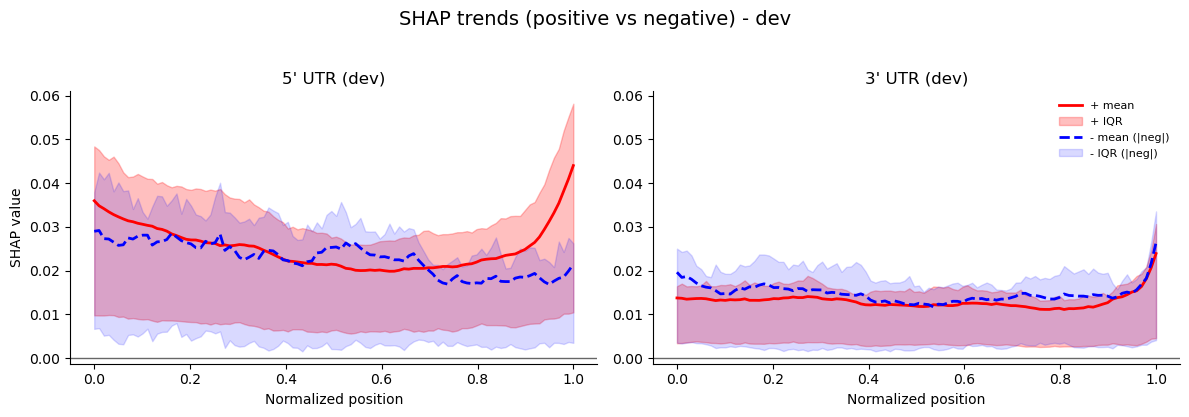

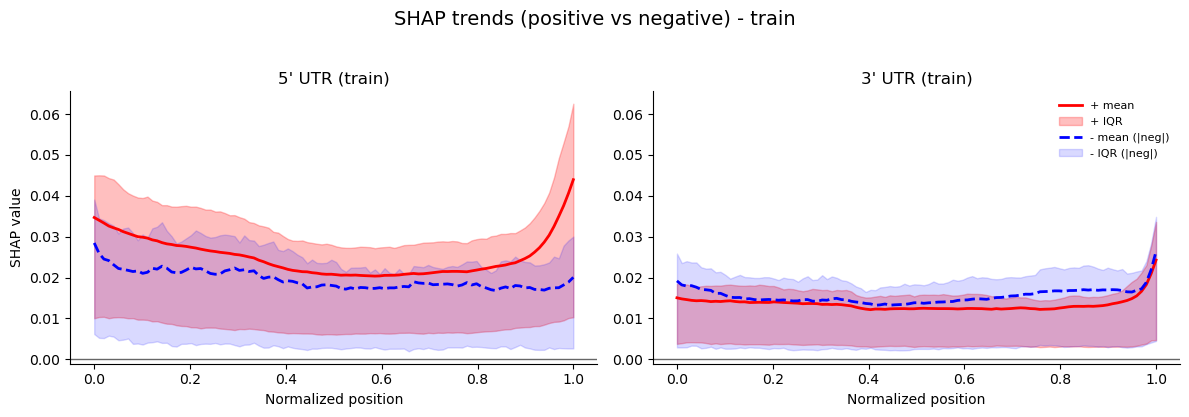

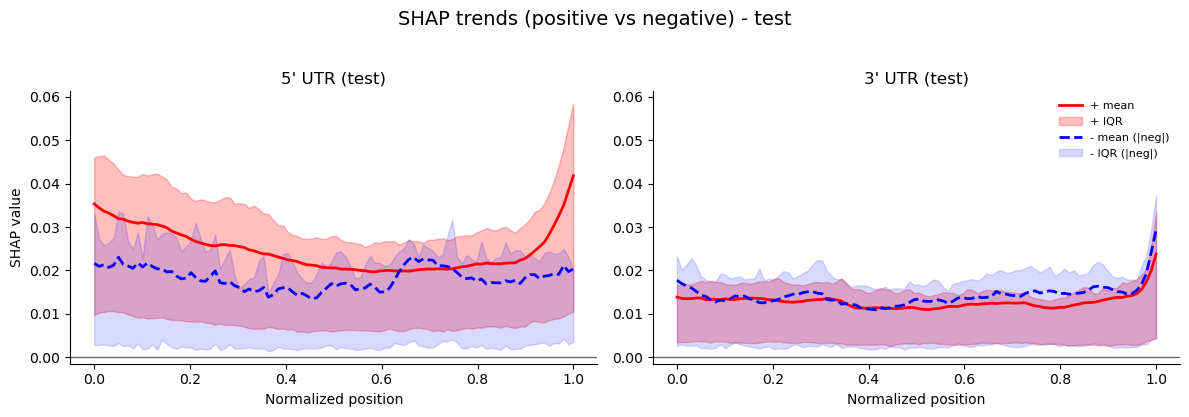

In [ ]:
# Split dev / train / test into separate figures (each with 5' and 3' panels)

target_len = 100  # keep existing interpolation length

def aggregate_pos_neg(sequences, tgt_len):
    pos_list, neg_list = [], []
    x_new = np.linspace(0, 1, tgt_len)
    for seq in sequences:
        if len(seq) < 2:
            continue
        x_old = np.linspace(0, 1, len(seq))
        seq_new = interp1d(x_old, seq, kind="linear")(x_new)
        pos_list.append(np.where(seq_new > 0, seq_new, np.nan))
        neg_list.append(np.where(seq_new < 0, -seq_new, np.nan))  # store magnitudes
    def stats(stack):
        if not stack:
            return dict(mean=None, p25=None, p75=None)
        arr = np.vstack(stack)
        with np.errstate(all='ignore'):
            return dict(
                mean=np.nanmean(arr, axis=0),
                p25=np.nanpercentile(arr, 25, axis=0),
                p75=np.nanpercentile(arr, 75, axis=0)
            )
    return stats(pos_list), stats(neg_list), x_new

# Helper to (non-destructively) truncate sequences like before
def truncate_list(seq_list, limit):
    return [s[-min(len(s), limit):] for s in seq_list]

group_color = {'dev': 'blue', 'train': 'red', 'test': 'green'}

for group in ['dev', 'train', 'test']:
    # Prepare (do not mutate originals)
    trunc5 = seqs5[group] #truncate_list(seqs5[group], 100)
    trunc3 = seqs3[group] #truncate_list(seqs3[group], 150)

    # Aggregate
    pos5, neg5, x5 = aggregate_pos_neg(trunc5, target_len)
    pos3, neg3, x3 = aggregate_pos_neg(trunc3, target_len)

    # Determine shared y-range for the figure
    y_min, y_max = np.inf, -np.inf
    for st in (pos5, neg5, pos3, neg3):
        if st['mean'] is not None:
            y_min = min(y_min, np.nanmin(st['p25']))
            y_max = max(y_max, np.nanmax(st['p75']))
    if not np.isfinite(y_min):
        y_min, y_max = -0.01, 0.01
    pad = 0.05 * (y_max - y_min if y_max > y_min else 1)

    fig, (ax5, ax3) = plt.subplots(1, 2, figsize=(12, 4))
    color = group_color[group]

    def plot_panel(ax, pos_stats, neg_stats, x_new, title):
        if pos_stats['mean'] is not None:
            ax.plot(x_new, pos_stats['mean'], color='red', lw=2, label='+ mean')
            ax.fill_between(x_new, pos_stats['p25'], pos_stats['p75'],
                            color='red', alpha=0.25, label='+ IQR')
        if neg_stats['mean'] is not None:
            ax.plot(x_new, neg_stats['mean'], color='blue', lw=2, ls='--', label='- mean (|neg|)')
            ax.fill_between(x_new, neg_stats['p25'], neg_stats['p75'],
                            color='blue', alpha=0.15, label='- IQR (|neg|)')
        ax.axhline(0, color='black', lw=1, alpha=0.6)
        ax.set_title(f"{title} UTR ({group})")
        ax.set_xlabel("Normalized position")
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plot_panel(ax5, pos5, neg5, x5, "5'")
    plot_panel(ax3, pos3, neg3, x3, "3'")
    ax5.set_ylabel("SHAP value")
    handles, labels = ax3.get_legend_handles_labels()
    ax3.legend(handles, labels, frameon=False, fontsize=8)
    fig.suptitle(f"SHAP trends (positive vs negative) - {group}", y=1.03, fontsize=14)
    plt.tight_layout()
    plt.show()


In [93]:
# Split dev / train / test into separate figures (each with 5' and 3' panels)

target_len = 100  # keep existing interpolation length

def aggregate_pos_neg(sequences, tgt_len):
    pos_list, neg_list = [], []
    x_new = np.linspace(0, 1, tgt_len)
    for tmp in sequences:
        if len(tmp) < 2:
            continue
        seq = tmp.copy()
        x_old = np.linspace(0, 1, len(seq))
        seq_new = interp1d(x_old, seq, kind="linear")(x_new)
        pos_list.append(np.where(seq_new > 0, seq_new, np.nan))
        neg_list.append(np.where(seq_new < 0, -seq_new, np.nan))  # store magnitudes

    return pos_list, neg_list, x_new



interp = {'dev': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}, 'train': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}, 'test': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}}
for group in ['dev', 'train', 'test']:
    # Prepare (do not mutate originals)
    trunc5 = seqs5[group] #truncate_list(seqs5[group], 100)
    trunc3 = seqs3[group] #truncate_list(seqs3[group], 150)

    # Aggregate
    pos5, neg5, x5 = aggregate_pos_neg(trunc5, target_len)
    pos3, neg3, x3 = aggregate_pos_neg(trunc3, target_len)
    interp[group]['pos5'] = pos5
    interp[group]['neg5'] = neg5
    interp[group]['pos3'] = pos3
    interp[group]['neg3'] = neg3




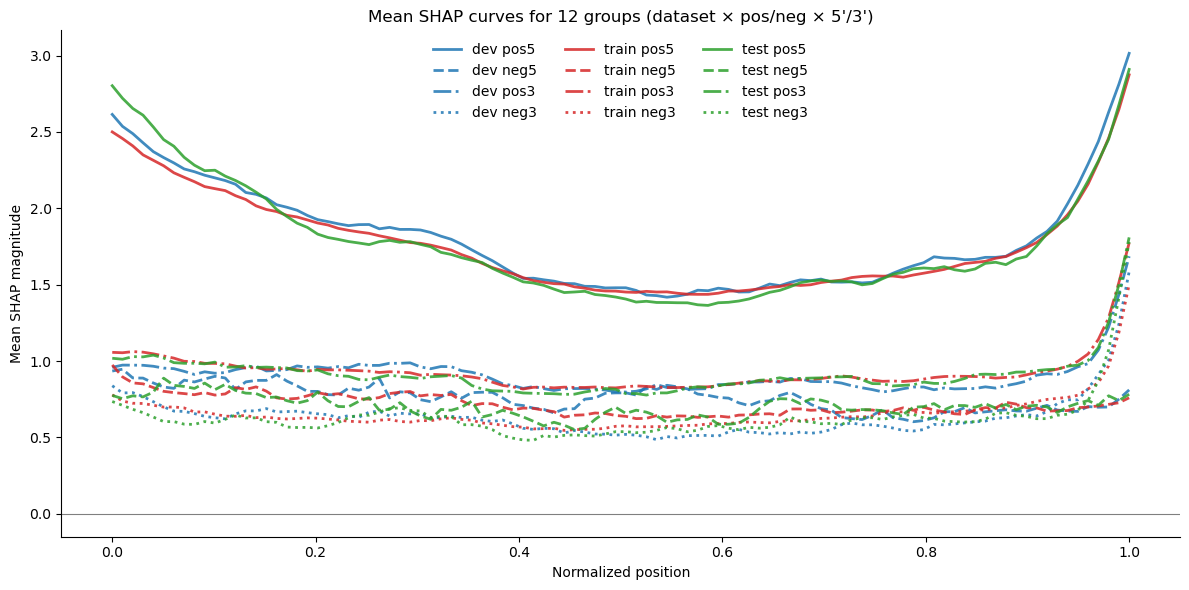

In [94]:
# Plot mean curve for each of the 12 (dataset x {pos5,neg5,pos3,neg3}) groups in one panel

# Assumes:
# - interp (from cell 6) exists: interp[dataset]['pos5'|'neg5'|'pos3'|'neg3'] -> list of arrays (length target_len)
# - target_len exists
# - np, plt imported

datasets = ['dev', 'train', 'test']
groups12 = ['pos5', 'neg5', 'pos3', 'neg3']
colors = {'dev': 'tab:blue', 'train': 'tab:red', 'test': 'tab:green'}

# Line style encoding
# UTR: 5' -> solid / 3' -> dash-dot
# sign: pos -> solid within base style, neg -> dashed overlay
utr_style = {'5': '-', '3': '-.'}
sign_style = {'pos': '', 'neg': '--'}  # appended

plt.figure(figsize=(12, 6))

x = np.linspace(0, 1, target_len)

for ds in datasets:
    for grp in groups12:
        seq_list = interp[ds][grp]
        if not seq_list:
            continue
        # Ensure consistent length and stack
        valid = [a for a in seq_list if isinstance(a, np.ndarray) and len(a) == target_len]
        if not valid:
            continue
        arr = np.vstack(valid)
        mean_curve = np.nanmean(arr, axis=0)

        # Derive styles
        sign = 'pos' if grp.startswith('pos') else 'neg'
        utr = '5' if '5' in grp else '3'
        base_ls = utr_style[utr]
        # Combine UTR and sign styles (if sign is neg, override with dashed)
        ls = sign_style[sign] if sign == 'neg' else base_ls
        if sign == 'pos' and utr == '3':
            ls = base_ls  # keep dash-dot for 3' pos
        if sign == 'neg' and utr == '3':
            ls = ':'  # differentiate 3' neg further

        label = f"{ds} {grp}"
        plt.plot(x, mean_curve, color=colors[ds], linestyle=ls, linewidth=2, alpha=0.85, label=label)

plt.axhline(0, color='black', lw=0.8, alpha=0.5)
plt.xlabel("Normalized position")
plt.ylabel("Mean SHAP magnitude")
plt.title("Mean SHAP curves for 12 groups (dataset × pos/neg × 5'/3')")
plt.legend(frameon=False, ncol=3)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig("figures/SHAP_mean_12_groups_single_panel.svg", bbox_inches='tight')
plt.show()

In [78]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import pandas as pd
import scipy.stats as stats

groups = ['dev', 'train', 'test']

def mixed_pos_neg(interp, pos_key, neg_key, alpha=0.05):
    records = []
    for g in groups:
        if pos_key not in interp[g] or neg_key not in interp[g]:
            continue
        for seq in interp[g][pos_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'pos', 'value': val})
        for seq in interp[g][neg_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'neg', 'value': val})

    df = pd.DataFrame.from_records(records).dropna(subset=['value'])
    if df.empty:
        return pd.DataFrame()

    results = []
    for pos in sorted(df.position.unique()):
        df_pos = df[df.position == pos]
        if df_pos.sign.nunique() < 2:
            results.append({"position": pos})
            continue
        try:
            fit = smf.ols("value ~ sign + dataset", df_pos).fit()
        except Exception:
            results.append({"position": pos})
            continue

        # Parameters
        b0 = fit.params.get("Intercept", np.nan)          # mean_neg
        b1_name = [p for p in fit.params.index if p.startswith("sign")][0]
        b1 = fit.params[b1_name]                          # diff = mean_pos - mean_neg
        V = fit.cov_params()
        V00 = V.loc["Intercept", "Intercept"]
        V11 = V.loc[b1_name, b1_name]
        V01 = V.loc["Intercept", b1_name]

        mean_neg = b0
        mean_pos = b0 + b1
        se_diff = np.sqrt(V11)

        # Raw p-value for diff
        pval = fit.pvalues[b1_name]

        # Standard 95% CIs (optional)
        tcrit_std = stats.t.ppf(1 - 0.05/2, fit.df_resid)
        se_neg = np.sqrt(V00)
        se_pos = np.sqrt(V00 + V11 + 2*V01)
        ci_neg = (mean_neg - tcrit_std*se_neg, mean_neg + tcrit_std*se_neg)
        ci_pos = (mean_pos - tcrit_std*se_pos, mean_pos + tcrit_std*se_pos)

        # Comparison intervals (non-overlap ⇔ p < alpha)
        tcrit = stats.t.ppf(1 - alpha/2, fit.df_resid)
        h = tcrit * se_diff / 2.0
        comp_neg = (mean_neg - h, mean_neg + h)
        comp_pos = (mean_pos - h, mean_pos + h)

        results.append({
            "position": pos,
            "mean_neg": mean_neg,
            "mean_pos": mean_pos,
            "p_raw": pval,
            "ci_neg_lower": ci_neg[0], "ci_neg_upper": ci_neg[1],
            "ci_pos_lower": ci_pos[0], "ci_pos_upper": ci_pos[1],
            "comp_neg_lower": comp_neg[0], "comp_neg_upper": comp_neg[1],
            "comp_pos_lower": comp_pos[0], "comp_pos_upper": comp_pos[1]
        })

    res_df = pd.DataFrame(results)
    if not res_df.empty and res_df.p_raw.notna().any():
        res_df["p_adj"] = multipletests(res_df.p_raw.fillna(1.0), method="fdr_bh")[1]
    else:
        res_df["p_adj"] = np.nan
    return res_df#, fit

res_5 = mixed_pos_neg(interp, 'pos5', 'neg5')
res_3 = mixed_pos_neg(interp, 'pos3', 'neg3')


In [47]:
fit1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  value   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     109.3
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           7.13e-69
Time:                        11:41:19   Log-Likelihood:                -6491.4
No. Observations:                5935   AIC:                         1.299e+04
Df Residuals:                    5931   BIC:                         1.302e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.3390      0.039      8.738      0.000       0.263       0.415
sign[T.pos]          0.6028      0.033     18.105      0.000       0.538       0.668
dataset[T.test]      0.0021      0.034      0.061      0.951      -0.065       0.069
dataset[T.train]     0.0032      0.027      0.118      0.906      -0.049       0.056
==============================================================================
Omnibus:                     2623.552   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            20531.968
Skew:                           1.938   Prob(JB):                         0.00
Kurtosis:                      11.246   Cond. No.                         8.64
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

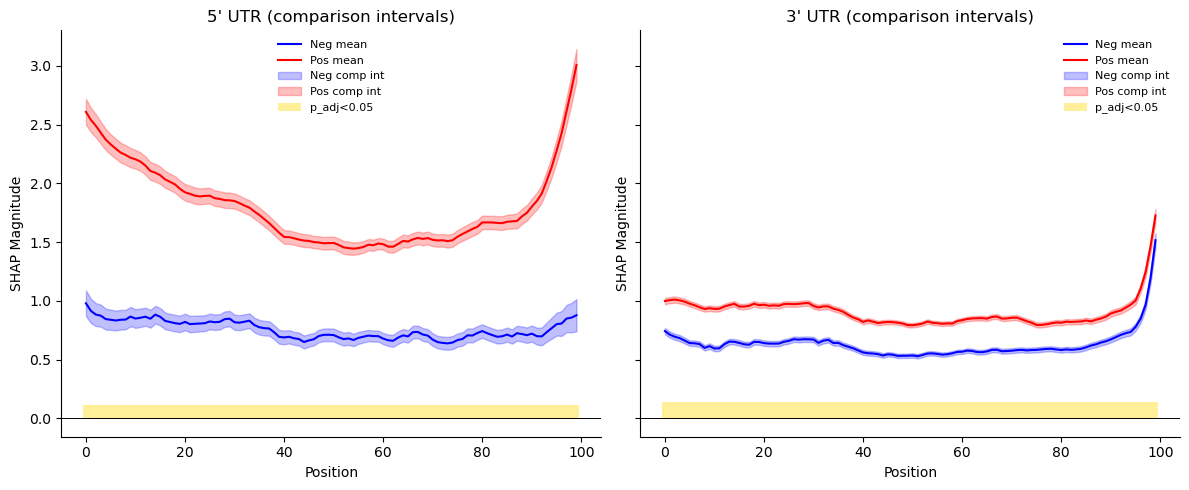

In [79]:


def plot_res(res_df, ax, title):
    if res_df.empty:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    ax.plot(res_df['position'], res_df['mean_neg'], color='blue', label='Neg mean')
    ax.plot(res_df['position'], res_df['mean_pos'], color='red', label='Pos mean')
    # Optionally mark where diff CI excludes 0:
    if {"diff_ci_lower","diff_ci_upper"}.issubset(res_df.columns):
        sig_mask = (res_df["diff_ci_lower"] > 0) | (res_df["diff_ci_upper"] < 0)
        ax.scatter(res_df.loc[sig_mask,"position"],
                   [0]*sig_mask.sum(),
                   color="gold", s=25, zorder=3, label="Diff CI excludes 0")

    neg_lower = res_df['ci_neg_lower']
    neg_upper = res_df['ci_neg_upper']
    pos_lower = res_df['ci_pos_lower']
    pos_upper = res_df['ci_pos_upper']

    ax.fill_between(res_df['position'], neg_lower, neg_upper, color='blue', alpha=0.25, label='Neg 95% CI')
    ax.fill_between(res_df['position'], pos_lower, pos_upper, color='red', alpha=0.25, label='Pos 95% CI')

    # Highlight contiguous significant regions (p_adj < 0.05) with boxes at y=0
    if 'p_adj' in res_df.columns and res_df['p_adj'].notna().any():
        sig_positions = sorted(res_df.loc[res_df['p_adj'] < 0.05, 'position'].unique())
        if sig_positions:
            # Build contiguous ranges
            ranges = []
            for p in sig_positions:
                if not ranges or p != ranges[-1][1] + 1:
                    ranges.append([p, p])
                else:
                    ranges[-1][1] = p
            # Determine a small box height
            ymin, ymax = ax.get_ylim()
            height = (ymax - ymin) * 0.04  # 4% of y-range
            import matplotlib.patches as patches
            added_label = False
            for start, end in ranges:
                # Expand half step to make the box span the positions nicely
                x0 = start - 0.5
                width = (end - start + 1)
                rect = patches.Rectangle(
                    (x0, 0), width, height,
                    facecolor='gold', edgecolor='none', alpha=0.4,
                    zorder=0.1,
                    label='p_adj<0.05' if not added_label else None
                )
                ax.add_patch(rect)
                added_label = True
            # Ensure zero line visible on top of rectangles
    ax.axhline(0, color='black', lw=0.8, alpha=0.5, zorder=1)

    ax.set_xlabel("Position")
    ax.set_ylabel("Magnitude")
    ax.set_title(title)
    ax.legend(frameon=False)

#fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
#plot_res(res_5, axes[0], "pos5 vs neg5 mixed model")
#plot_res(res_3, axes[1], "pos3 vs neg3 mixed model")
#
#plt.tight_layout()
#plt.show()

def plot_comparison(res_df, ax, title, use_comp=True):
    if res_df.empty:
        ax.text(0.5,0.5,"No data",ha='center',va='center')
        ax.set_title(title)
        return
    ax.plot(res_df.position, res_df.mean_neg, color='blue', label='Neg mean')
    ax.plot(res_df.position, res_df.mean_pos, color='red', label='Pos mean')

    if use_comp:
        # Comparison intervals
        ax.fill_between(res_df.position, res_df.comp_neg_lower, res_df.comp_neg_upper,
                        color='blue', alpha=0.25, label='Neg comp int')
        ax.fill_between(res_df.position, res_df.comp_pos_lower, res_df.comp_pos_upper,
                        color='red', alpha=0.25, label='Pos comp int')
        # Mark significant where intervals do not overlap
        # Highlight contiguous significant regions (p_adj < 0.05) with boxes at y=0
        if 'p_adj' in res_df.columns and res_df['p_adj'].notna().any():
            sig_positions = sorted(res_df.loc[res_df['p_adj'] < 0.05, 'position'].unique())
            if sig_positions:
                # Build contiguous ranges
                ranges = []
                for p in sig_positions:
                    if not ranges or p != ranges[-1][1] + 1:
                        ranges.append([p, p])
                    else:
                        ranges[-1][1] = p
                # Determine a small box height
                ymin, ymax = ax.get_ylim()
                height = (ymax - ymin) * 0.04  # 4% of y-range
                import matplotlib.patches as patches
                added_label = False
                for start, end in ranges:
                    # Expand half step to make the box span the positions nicely
                    x0 = start - 0.5
                    width = (end - start + 1)
                    rect = patches.Rectangle(
                        (x0, 0), width, height,
                        facecolor='gold', edgecolor='none', alpha=0.4,
                        zorder=0.1,
                        label='p_adj<0.05' if not added_label else None
                    )
                    ax.add_patch(rect)
                    added_label = True
    else:
        # Standard 95% CIs
        ax.fill_between(res_df.position, res_df.ci_neg_lower, res_df.ci_neg_upper,
                        color='blue', alpha=0.25, label='Neg 95% CI')
        ax.fill_between(res_df.position, res_df.ci_pos_lower, res_df.ci_pos_upper,
                        color='red', alpha=0.25, label='Pos 95% CI')

    ax.axhline(0, color='black', lw=0.7)
    ax.set_title(title + (" (comparison intervals)" if use_comp else " (95% CIs)"))
    ax.set_xlabel("Position")
    ax.set_ylabel("SHAP Magnitude")
    ax.legend(frameon=False, fontsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Example usage:
res_5 = mixed_pos_neg(interp, 'pos5', 'neg5', alpha=0.05)
res_3 = mixed_pos_neg(interp, 'pos3', 'neg3', alpha=0.05)

fig, axes = plt.subplots(1,2, figsize=(12,5), sharey=True)
plot_comparison(res_5, axes[0], "5' UTR")
plot_comparison(res_3, axes[1], "3' UTR")
plt.tight_layout()
plt.savefig('figures/SHAP_trends_pos_vs_neg_comparison_intervals.svg', bbox_inches='tight')
plt.show()


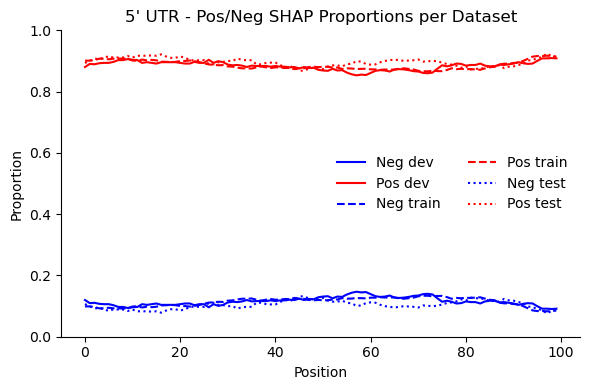

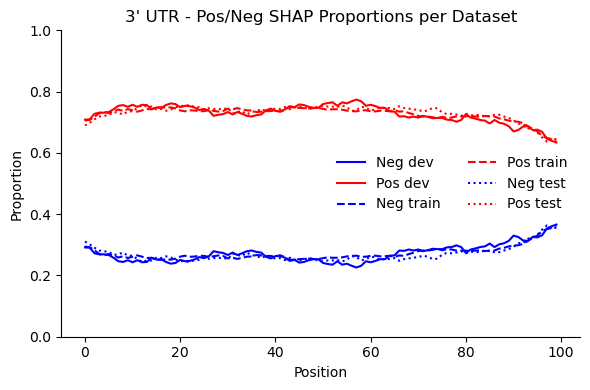

In [80]:
# Plot per-dataset curves (no averaging across datasets)
linestyles = {'dev': '-', 'train': '--', 'test': ':'}
for pos_key, neg_key in [('pos5','neg5'), ('pos3','neg3')]:
    label = "5' UTR" if pos_key == 'pos5' else "3' UTR"
    
    # Collect records
    records = []
    for g in groups:
        if pos_key not in interp[g] or neg_key not in interp[g]:
            continue
        for seq in interp[g][pos_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'pos', 'value': val})
        for seq in interp[g][neg_key]:
            for pos, val in enumerate(seq):
                records.append({'dataset': g, 'position': pos, 'sign': 'neg', 'value': val})

    df = pd.DataFrame.from_records(records).dropna(subset=['value'])
    if df.empty:
        continue

    plt.figure(figsize=(6,4))
    for g in groups:
        sub = df[df.dataset == g]
        if sub.empty:
            continue
        counts_g = sub.groupby(['position','sign']).size().unstack('sign').fillna(0)
        # Ensure both columns exist
        for s in ['pos','neg']:
            if s not in counts_g.columns:
                counts_g[s] = 0
        props = counts_g.div(counts_g.sum(axis=1), axis=0).fillna(0)
        plt.plot(props.index, props['neg'], color='blue', linestyle=linestyles[g], label=f'Neg {g}')
        plt.plot(props.index, props['pos'], color='red', linestyle=linestyles[g], label=f'Pos {g}')

    plt.xlabel('Position')
    plt.ylabel('Proportion')
    plt.title(f"{label} - Pos/Neg SHAP Proportions per Dataset")
    plt.axhline(0, color='black', lw=0.5, alpha=0.6)
    plt.ylim(0,1)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.savefig(f'figures/SHAP_trends_{pos_key}_vs_{neg_key}_per_dataset.svg', bbox_inches='tight')
    plt.show()


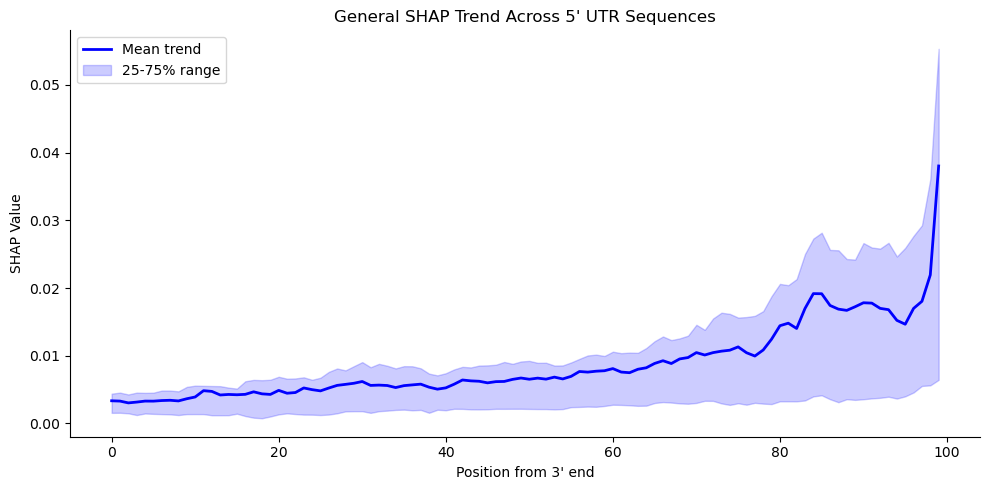

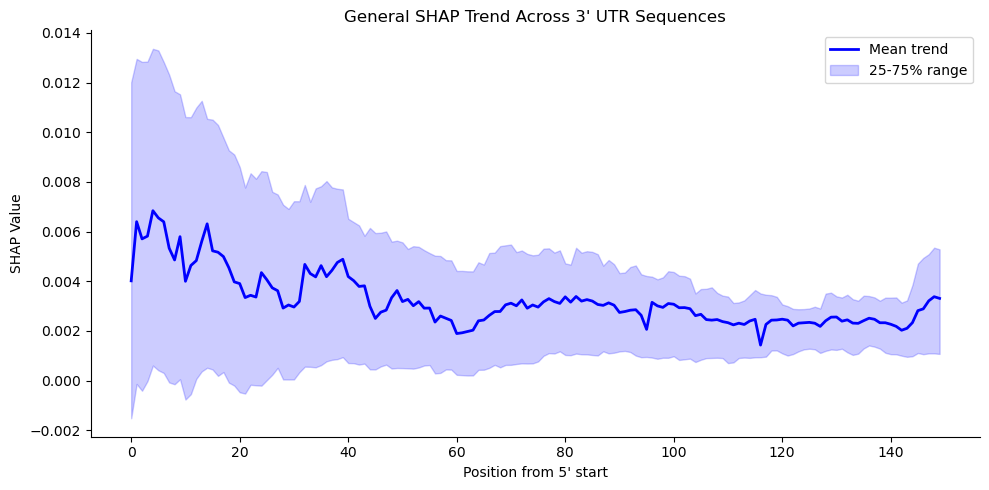

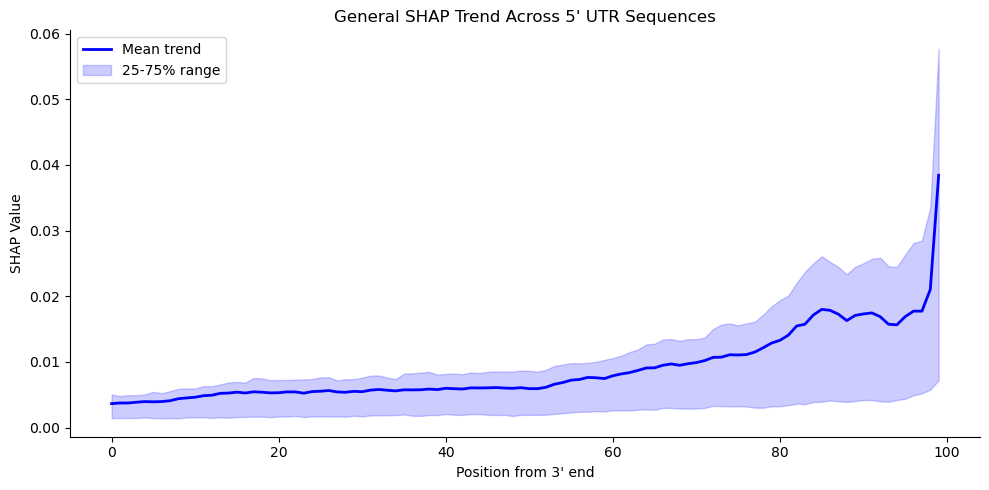

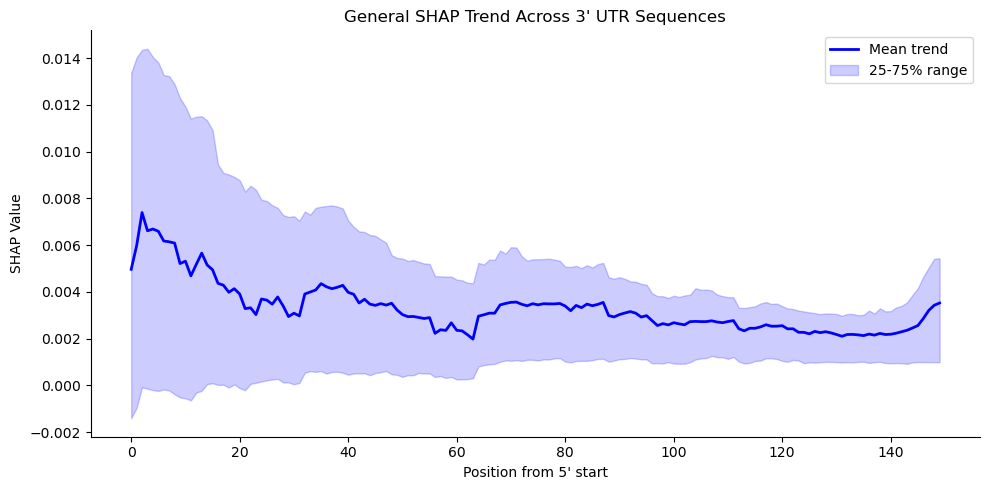

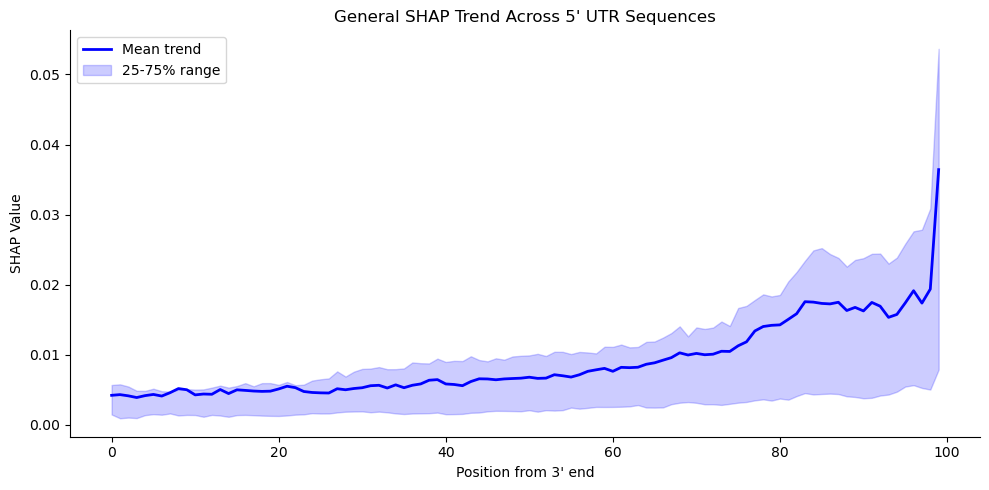

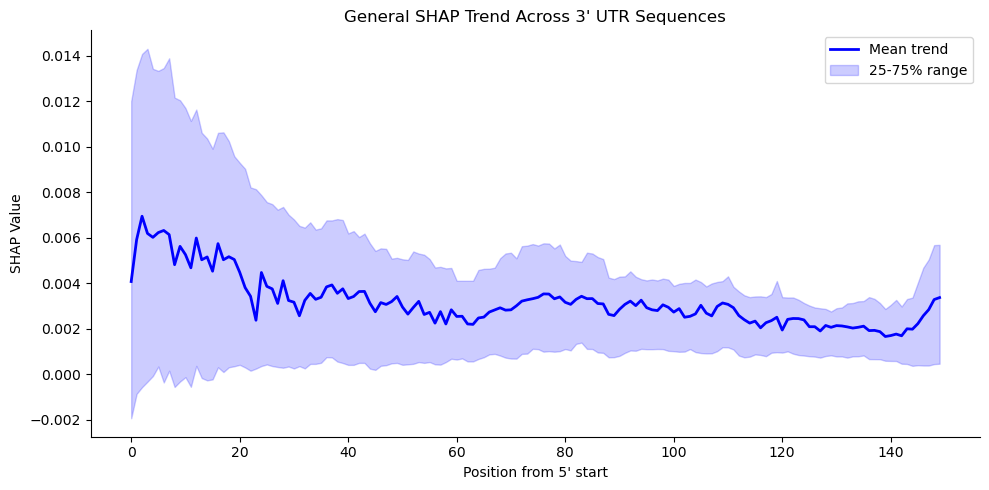

In [86]:
import numpy as np

import matplotlib.pyplot as plt

padded_seqs5 = {'dev': [], 'train': [], 'test': []}
padded_seqs3 = {'dev': [], 'train': [], 'test': []}
for group in ['dev','train','test']:
    # Determine max length for padding
    max_len_5 = max(len(seq) for seq in seqs5[group])
    max_len_3 = max(len(seq) for seq in seqs3[group])
    
    # Pad sequences with NaN
    # For 5' UTR: pad at the beginning (so sequences end at the same time)
    padded_seqs5[group] = []
    for seq in seqs5[group]:
        padding_length = max_len_5 - len(seq)
        padded_seq = np.concatenate([np.full(padding_length, np.nan), seq])
        padded_seqs5[group].append(padded_seq)
    
    # For 3' UTR: pad at the end (so sequences start at the same time)
    padded_seqs3[group] = []
    for seq in seqs3[group]:
        padding_length = max_len_3 - len(seq)
        padded_seq = np.concatenate([seq, np.full(padding_length, np.nan)])
        padded_seqs3[group].append(padded_seq)
    
    # Convert to arrays
    padded_seqs5[group] = np.array(padded_seqs5[group])
    padded_seqs3[group] = np.array(padded_seqs3[group])
    
    # Calculate mean and percentiles ignoring NaN values
    for sequences, title, x_label in [(padded_seqs5[group], "5' UTR", "Position from 3' end"), 
                                      (padded_seqs3[group], "3' UTR", "Position from 5' start")]:
        
        # Compute mean and percentiles ignoring NaN
        mean_trend = np.nanmean(sequences, axis=0)
        p25 = np.nanpercentile(sequences, 25, axis=0)
        p75 = np.nanpercentile(sequences, 75, axis=0)
        
        # Plot
        plt.figure(figsize=(10, 5))
        
        plt.plot(mean_trend, color="blue", linewidth=2, label="Mean trend")
        plt.fill_between(range(len(mean_trend)), p25, p75, color="blue", alpha=0.2, label="25-75% range")
        plt.title(f"{group}: General SHAP Trend Across {title} Sequences")
        plt.xlabel(x_label)
        plt.ylabel("SHAP Value")
        plt.legend()
        
        # Remove top and right spines
        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        plt.tight_layout()
        #plt.savefig(f'figures/SHAP_trend_{title.replace("'", "").replace(" ", "_")}.svg')
        plt.show()


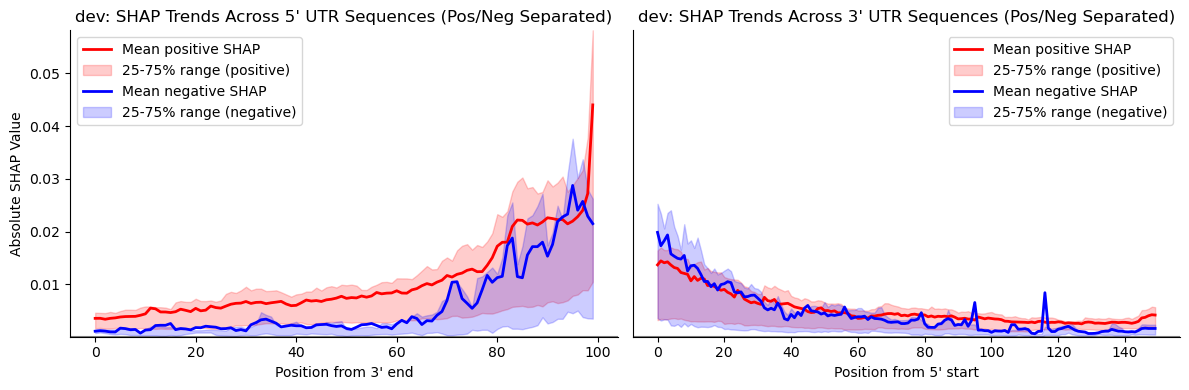

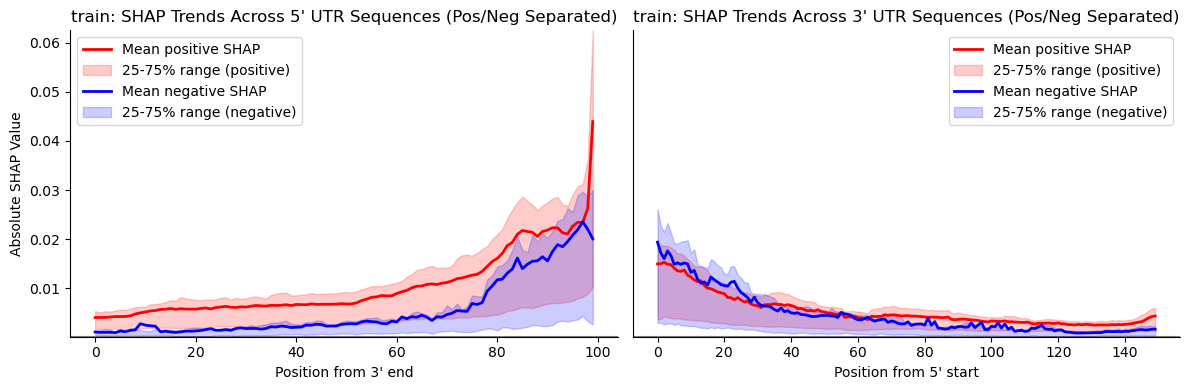

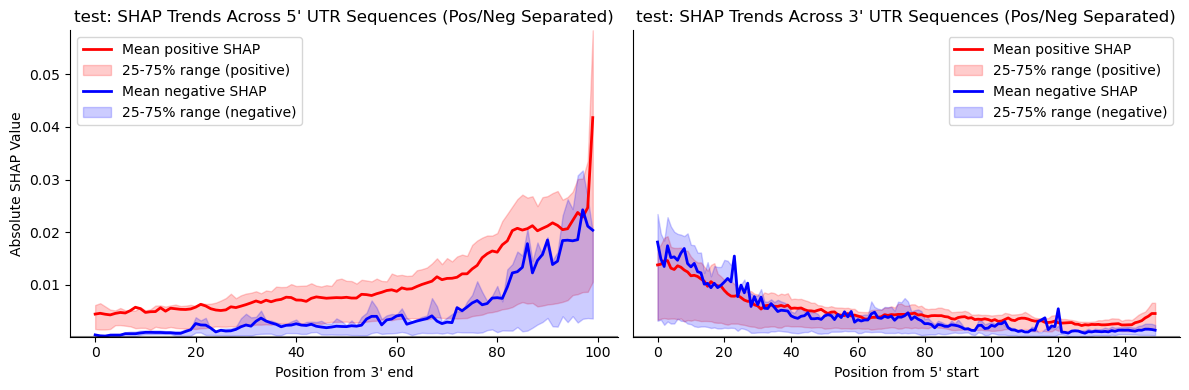

In [98]:
import numpy as np

import matplotlib.pyplot as plt


pos_seqs5 = {'dev':[], 'train':[], 'test':[]}
neg_seqs5 = {'dev':[], 'train':[], 'test':[]}
pos_seqs3 = {'dev':[], 'train':[], 'test':[]}
neg_seqs3 = {'dev':[], 'train':[], 'test':[]}
padded_pos_seqs5 = {'dev':[], 'train':[], 'test':[]}
padded_neg_seqs5 = {'dev':[], 'train':[], 'test':[]}
padded_pos_seqs3 = {'dev':[], 'train':[], 'test':[]}
padded_neg_seqs3 = {'dev':[], 'train':[], 'test':[]}
for group in ['dev', 'train', 'test']:
# Separate positive and negative values for each sequence
    
    for seq in seqs5[group]:
        pos_vals = np.where(seq > 0, seq, np.nan)
        neg_vals = np.where(seq < 0, seq, np.nan)
        pos_seqs5[group].append(pos_vals)
        neg_seqs5[group].append(neg_vals)
    
    for seq in seqs3[group]:
        pos_vals = np.where(seq > 0, seq, np.nan)
        neg_vals = np.where(seq < 0, seq, np.nan)
        pos_seqs3[group].append(pos_vals)
        neg_seqs3[group].append(neg_vals)
    
    # Determine max length for padding
    max_len_5 = max(len(seq) for seq in seqs5[group])
    max_len_3 = max(len(seq) for seq in seqs3[group])
    
    # Pad sequences with NaN
    # For 5' UTR: pad at the beginning (so sequences end at the same time)
    padded_pos_seqs5[group] = []
    padded_neg_seqs5[group] = []
    for seq_pos, seq_neg in zip(pos_seqs5[group], neg_seqs5[group]):
        padding_length = max_len_5 - len(seq_pos)
        padded_pos = np.concatenate([np.full(padding_length, np.nan), seq_pos])
        padded_neg = np.concatenate([np.full(padding_length, np.nan), seq_neg])
        padded_pos_seqs5[group].append(padded_pos)
        padded_neg_seqs5[group].append(padded_neg)
    
    # For 3' UTR: pad at the end (so sequences start at the same time)
    padded_pos_seqs3[group] = []
    padded_neg_seqs3[group] = []
    for seq_pos, seq_neg in zip(pos_seqs3[group], neg_seqs3[group]):
        padding_length = max_len_3 - len(seq_pos)
        padded_pos = np.concatenate([seq_pos, np.full(padding_length, np.nan)])
        padded_neg = np.concatenate([seq_neg, np.full(padding_length, np.nan)])
        padded_pos_seqs3[group].append(padded_pos)
        padded_neg_seqs3[group].append(padded_neg)
    
    # Convert to arrays
    padded_pos_seqs5[group] = np.array(padded_pos_seqs5[group])
    padded_neg_seqs5[group] = -np.array(padded_neg_seqs5[group])
    padded_pos_seqs3[group] = np.array(padded_pos_seqs3[group])
    padded_neg_seqs3[group] = -np.array(padded_neg_seqs3[group])
    
    # Plot both 5' and 3' UTR on same figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # 5' UTR plot
    y_min = float('inf')
    y_max = float('-inf')

    # First pass: calculate global y-axis range
    for pos_data, neg_data, title, x_label, ax in [(padded_pos_seqs5[group], padded_neg_seqs5[group], "5' UTR", "Position from 3' end", ax1),
                                                   (padded_pos_seqs3[group], padded_neg_seqs3[group], "3' UTR", "Position from 5' start", ax2)]:
        
        # Calculate mean and percentiles for positive values
        mean_pos = np.nanmean(pos_data, axis=0)
        p25_pos = np.nanpercentile(pos_data, 25, axis=0)
        p75_pos = np.nanpercentile(pos_data, 75, axis=0)
        
        # Calculate mean and percentiles for negative values
        mean_neg = np.nanmean(neg_data, axis=0)
        p25_neg = np.nanpercentile(neg_data, 25, axis=0)
        p75_neg = np.nanpercentile(neg_data, 75, axis=0)
        
        # Update global y-axis range
        y_min = min(y_min, np.nanmin(p25_pos), np.nanmin(p25_neg))
        y_max = max(y_max, np.nanmax(p75_pos), np.nanmax(p75_neg))

    # Second pass: create plots with shared y-axis range
    for i, (pos_data, neg_data, title, x_label, ax) in enumerate([(padded_pos_seqs5[group], padded_neg_seqs5[group], "5' UTR", "Position from 3' end", ax1),
                                                                  (padded_pos_seqs3[group], padded_neg_seqs3[group], "3' UTR", "Position from 5' start", ax2)]):
        
        # Calculate mean and percentiles for positive values
        mean_pos = np.nanmean(pos_data, axis=0)
        p25_pos = np.nanpercentile(pos_data, 25, axis=0)
        p75_pos = np.nanpercentile(pos_data, 75, axis=0)
        
        # Calculate mean and percentiles for negative values
        mean_neg = np.nanmean(neg_data, axis=0)
        p25_neg = np.nanpercentile(neg_data, 25, axis=0)
        p75_neg = np.nanpercentile(neg_data, 75, axis=0)
        
        # Plot positive values
        ax.plot(mean_pos, color="red", linewidth=2, label="Mean positive SHAP")
        ax.fill_between(range(len(mean_pos)), p25_pos, p75_pos, color="red", alpha=0.2, label="25-75% range (positive)")
        
        # Plot negative values
        ax.plot(mean_neg, color="blue", linewidth=2, label="Mean negative SHAP")
        ax.fill_between(range(len(mean_neg)), p25_neg, p75_neg, color="blue", alpha=0.2, label="25-75% range (negative)")
        
        # Add zero line
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        
        # Set shared y-axis range
        ax.set_ylim(y_min, y_max)
        
        ax.set_title(f"{group}: SHAP Trends Across {title} Sequences (Pos/Neg Separated)")
        ax.set_xlabel(x_label)
        
        # Only show y-axis label and ticks for the first plot
        if i == 0:
            ax.set_ylabel("Absolute SHAP Value")
        else:
            ax.set_yticklabels([])
            ax.tick_params(left=False)
        
        ax.legend()
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    #plt.savefig('figures/SHAP_trend_pos_neg_separated.svg')
    plt.show()

In [ ]:
import numpy as np

import matplotlib.pyplot as plt


pos_seqs5 = {'dev':[], 'train':[], 'test':[]}
neg_seqs5 = {'dev':[], 'train':[], 'test':[]}
pos_seqs3 = {'dev':[], 'train':[], 'test':[]}
neg_seqs3 = {'dev':[], 'train':[], 'test':[]}
padded_pos_seqs5 = {'dev':[], 'train':[], 'test':[]}
padded_neg_seqs5 = {'dev':[], 'train':[], 'test':[]}
padded_pos_seqs3 = {'dev':[], 'train':[], 'test':[]}
padded_neg_seqs3 = {'dev':[], 'train':[], 'test':[]}
for group in ['dev', 'train', 'test']:
# Separate positive and negative values for each sequence
    
    for seq in seqs5[group]:
        pos_vals = np.where(seq > 0, seq, np.nan)
        neg_vals = np.where(seq < 0, seq, np.nan)
        pos_seqs5[group].append(pos_vals)
        neg_seqs5[group].append(neg_vals)
    
    for seq in seqs3[group]:
        pos_vals = np.where(seq > 0, seq, np.nan)
        neg_vals = np.where(seq < 0, seq, np.nan)
        pos_seqs3[group].append(pos_vals)
        neg_seqs3[group].append(neg_vals)
    
    # Determine max length for padding
    max_len_5 = max(len(seq) for seq in seqs5[group])
    max_len_3 = max(len(seq) for seq in seqs3[group])
    
    # Pad sequences with NaN
    # For 5' UTR: pad at the beginning (so sequences end at the same time)
    padded_pos_seqs5[group] = []
    padded_neg_seqs5[group] = []
    for seq_pos, seq_neg in zip(pos_seqs5[group], neg_seqs5[group]):
        padding_length = max_len_5 - len(seq_pos)
        padded_pos = np.concatenate([np.full(padding_length, np.nan), seq_pos])
        padded_neg = np.concatenate([np.full(padding_length, np.nan), seq_neg])
        padded_pos_seqs5[group].append(padded_pos)
        padded_neg_seqs5[group].append(padded_neg)
    
    # For 3' UTR: pad at the end (so sequences start at the same time)
    padded_pos_seqs3[group] = []
    padded_neg_seqs3[group] = []
    for seq_pos, seq_neg in zip(pos_seqs3[group], neg_seqs3[group]):
        padding_length = max_len_3 - len(seq_pos)
        padded_pos = np.concatenate([seq_pos, np.full(padding_length, np.nan)])
        padded_neg = np.concatenate([seq_neg, np.full(padding_length, np.nan)])
        padded_pos_seqs3[group].append(padded_pos)
        padded_neg_seqs3[group].append(padded_neg)
    
    # Convert to arrays
    padded_pos_seqs5[group] = np.array(padded_pos_seqs5[group])
    padded_neg_seqs5[group] = -np.array(padded_neg_seqs5[group])
    padded_pos_seqs3[group] = np.array(padded_pos_seqs3[group])
    padded_neg_seqs3[group] = -np.array(padded_neg_seqs3[group])
    
    # Plot both 5' and 3' UTR on same figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
    
    # 5' UTR plot
    y_min = float('inf')
    y_max = float('-inf')

    # First pass: calculate global y-axis range
    for pos_data, neg_data, title, x_label, ax in [(padded_pos_seqs5[group], padded_neg_seqs5[group], "5' UTR", "Position from 3' end", ax1),
                                                   (padded_pos_seqs3[group], padded_neg_seqs3[group], "3' UTR", "Position from 5' start", ax2)]:
        
        # Calculate mean and percentiles for positive values
        mean_pos = np.nanmean(pos_data, axis=0)
        p25_pos = np.nanpercentile(pos_data, 25, axis=0)
        p75_pos = np.nanpercentile(pos_data, 75, axis=0)
        
        # Calculate mean and percentiles for negative values
        mean_neg = np.nanmean(neg_data, axis=0)
        p25_neg = np.nanpercentile(neg_data, 25, axis=0)
        p75_neg = np.nanpercentile(neg_data, 75, axis=0)
        
        # Update global y-axis range
        y_min = min(y_min, np.nanmin(p25_pos), np.nanmin(p25_neg))
        y_max = max(y_max, np.nanmax(p75_pos), np.nanmax(p75_neg))

    # Second pass: create plots with shared y-axis range
    for i, (pos_data, neg_data, title, x_label, ax) in enumerate([(padded_pos_seqs5[group], padded_neg_seqs5[group], "5' UTR", "Position from 3' end", ax1),
                                                                  (padded_pos_seqs3[group], padded_neg_seqs3[group], "3' UTR", "Position from 5' start", ax2)]):
        
        # Calculate mean and percentiles for positive values
        mean_pos = np.nanmean(pos_data, axis=0)
        p25_pos = np.nanpercentile(pos_data, 25, axis=0)
        p75_pos = np.nanpercentile(pos_data, 75, axis=0)
        
        # Calculate mean and percentiles for negative values
        mean_neg = np.nanmean(neg_data, axis=0)
        p25_neg = np.nanpercentile(neg_data, 25, axis=0)
        p75_neg = np.nanpercentile(neg_data, 75, axis=0)
        
        # Plot positive values
        ax.plot(mean_pos, color="red", linewidth=2, label="Mean positive SHAP")
        ax.fill_between(range(len(mean_pos)), p25_pos, p75_pos, color="red", alpha=0.2, label="25-75% range (positive)")
        
        # Plot negative values
        ax.plot(mean_neg, color="blue", linewidth=2, label="Mean negative SHAP")
        ax.fill_between(range(len(mean_neg)), p25_neg, p75_neg, color="blue", alpha=0.2, label="25-75% range (negative)")
        
        # Add zero line
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        
        # Set shared y-axis range
        ax.set_ylim(y_min, y_max)
        
        ax.set_title(f"{group}: SHAP Trends Across {title} Sequences (Pos/Neg Separated)")
        ax.set_xlabel(x_label)
        
        # Only show y-axis label and ticks for the first plot
        if i == 0:
            ax.set_ylabel("Absolute SHAP Value")
        else:
            ax.set_yticklabels([])
            ax.tick_params(left=False)
        
        ax.legend()
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    #plt.savefig('figures/SHAP_trend_pos_neg_separated.svg')
    plt.show()

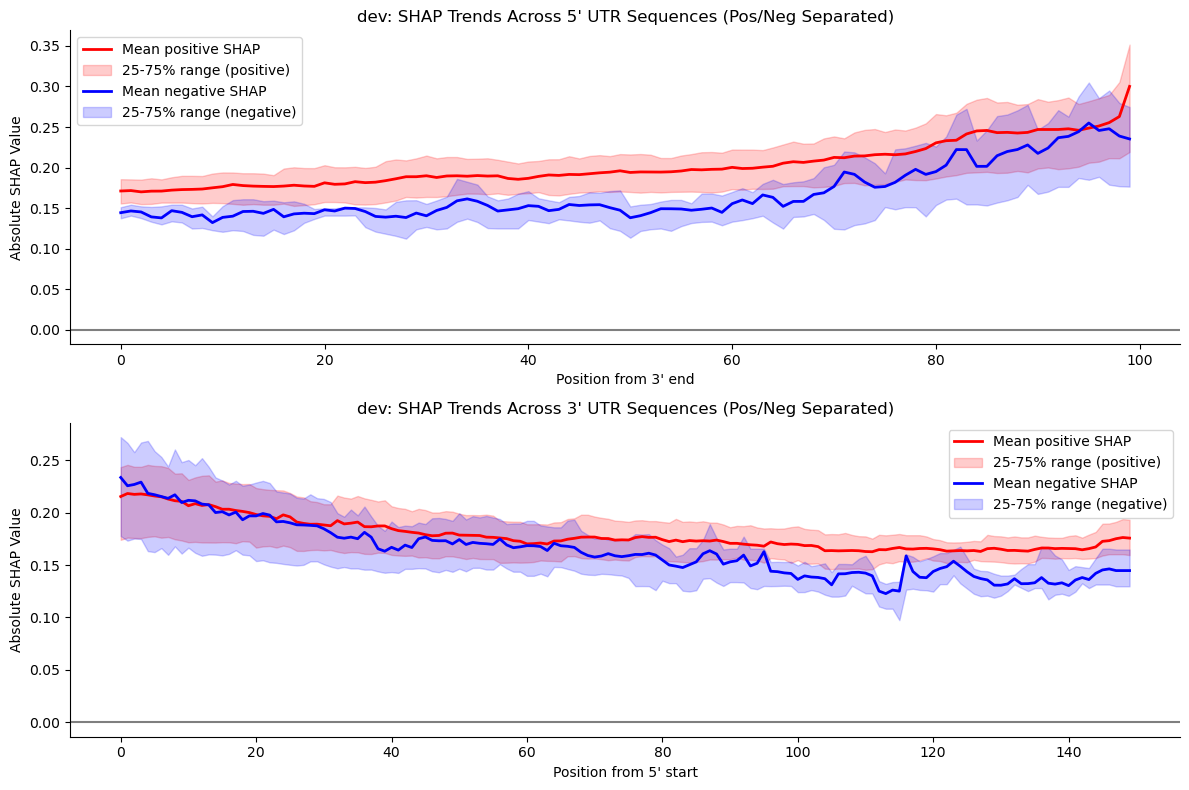

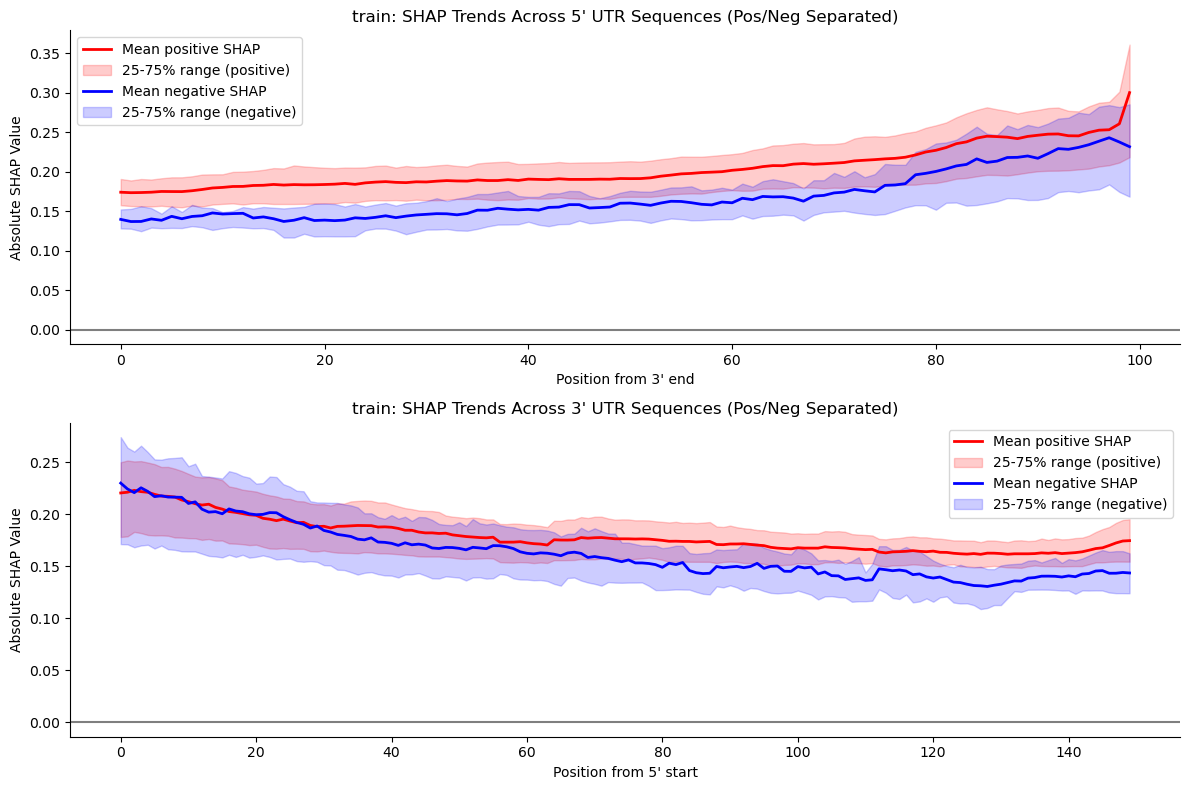

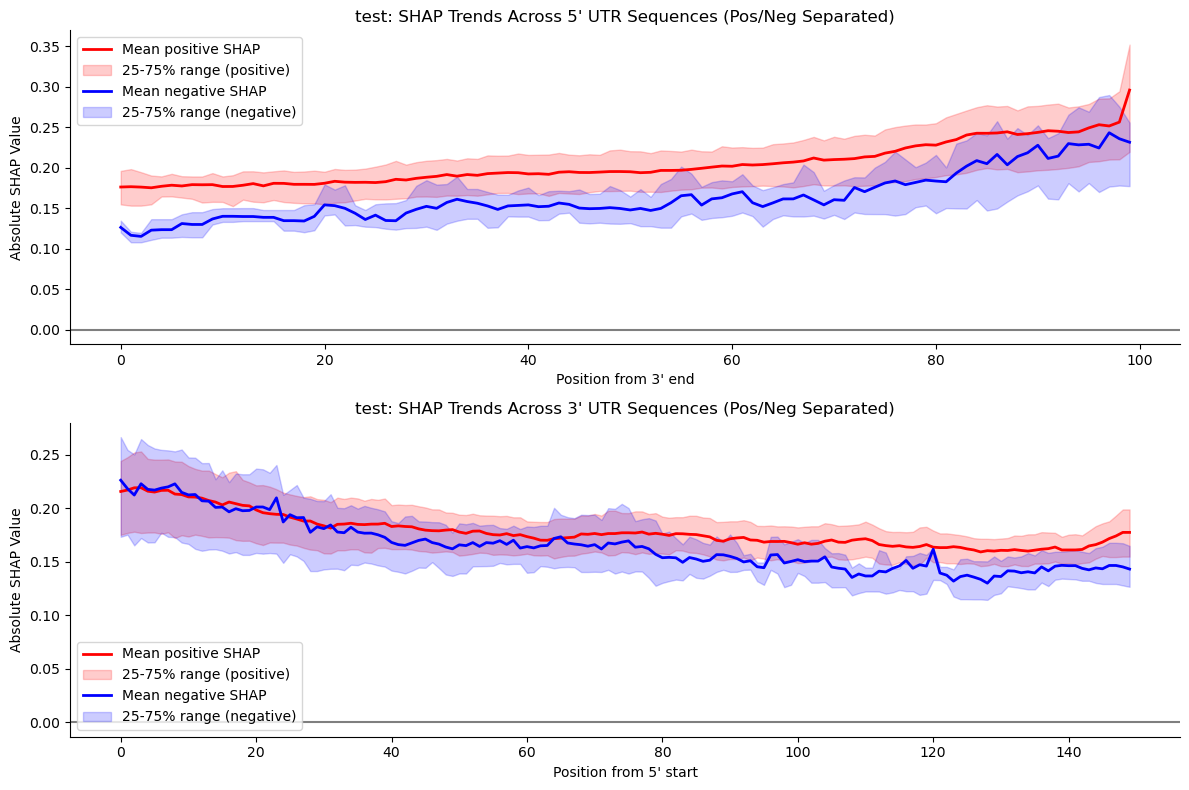

In [93]:
import numpy as np

import matplotlib.pyplot as plt


pos_seqs5 = {'dev':[], 'train':[], 'test':[]}
neg_seqs5 = {'dev':[], 'train':[], 'test':[]}
pos_seqs3 = {'dev':[], 'train':[], 'test':[]}
neg_seqs3 = {'dev':[], 'train':[], 'test':[]}
padded_pos_seqs5 = {'dev':[], 'train':[], 'test':[]}
padded_neg_seqs5 = {'dev':[], 'train':[], 'test':[]}
padded_pos_seqs3 = {'dev':[], 'train':[], 'test':[]}
padded_neg_seqs3 = {'dev':[], 'train':[], 'test':[]}
for group in ['dev', 'train', 'test']:
# Separate positive and negative values for each sequence
    
    for seq in seqs5[group]:
        pos_vals = np.where(seq > 0, seq, np.nan)
        neg_vals = np.where(seq < 0, seq, np.nan)
        pos_seqs5[group].append(pos_vals)
        neg_seqs5[group].append(neg_vals)
    
    for seq in seqs3[group]:
        pos_vals = np.where(seq > 0, seq, np.nan)
        neg_vals = np.where(seq < 0, seq, np.nan)
        pos_seqs3[group].append(pos_vals)
        neg_seqs3[group].append(neg_vals)
    
    # Determine max length for padding
    max_len_5 = max(len(seq) for seq in seqs5[group])
    max_len_3 = max(len(seq) for seq in seqs3[group])
    
    # Pad sequences with NaN
    # For 5' UTR: pad at the beginning (so sequences end at the same time)
    padded_pos_seqs5[group] = []
    padded_neg_seqs5[group] = []
    for seq_pos, seq_neg in zip(pos_seqs5[group], neg_seqs5[group]):
        padding_length = max_len_5 - len(seq_pos)
        padded_pos = np.concatenate([np.full(padding_length, np.nan), seq_pos])
        padded_neg = np.concatenate([np.full(padding_length, np.nan), seq_neg])
        padded_pos_seqs5[group].append(padded_pos)
        padded_neg_seqs5[group].append(padded_neg)
    
    # For 3' UTR: pad at the end (so sequences start at the same time)
    padded_pos_seqs3[group] = []
    padded_neg_seqs3[group] = []
    for seq_pos, seq_neg in zip(pos_seqs3[group], neg_seqs3[group]):
        padding_length = max_len_3 - len(seq_pos)
        padded_pos = np.concatenate([seq_pos, np.full(padding_length, np.nan)])
        padded_neg = np.concatenate([seq_neg, np.full(padding_length, np.nan)])
        padded_pos_seqs3[group].append(padded_pos)
        padded_neg_seqs3[group].append(padded_neg)
    
    # Convert to arrays
    padded_pos_seqs5[group] = -1/np.log(np.array(padded_pos_seqs5[group]))
    padded_neg_seqs5[group] = -1/np.log(-np.array(padded_neg_seqs5[group]))
    padded_pos_seqs3[group] = -1/np.log(np.array(padded_pos_seqs3[group]))
    padded_neg_seqs3[group] = -1/np.log(-np.array(padded_neg_seqs3[group]))
    
    # Plot both 5' and 3' UTR on same figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # 5' UTR plot
    for pos_data, neg_data, title, x_label, ax in [(padded_pos_seqs5[group], padded_neg_seqs5[group], "5' UTR", "Position from 3' end", ax1),
                                                   (padded_pos_seqs3[group], padded_neg_seqs3[group], "3' UTR", "Position from 5' start", ax2)]:
        
        # Calculate mean and percentiles for positive values
        mean_pos = np.nanmean(pos_data, axis=0)
        p25_pos = np.nanpercentile(pos_data, 25, axis=0)
        p75_pos = np.nanpercentile(pos_data, 75, axis=0)
        
        # Calculate mean and percentiles for negative values
        mean_neg = np.nanmean(neg_data, axis=0)
        p25_neg = np.nanpercentile(neg_data, 25, axis=0)
        p75_neg = np.nanpercentile(neg_data, 75, axis=0)
        
        # Plot positive values
        ax.plot(mean_pos, color="red", linewidth=2, label="Mean positive SHAP")
        ax.fill_between(range(len(mean_pos)), p25_pos, p75_pos, color="red", alpha=0.2, label="25-75% range (positive)")
        
        # Plot negative values
        ax.plot(mean_neg, color="blue", linewidth=2, label="Mean negative SHAP")
        ax.fill_between(range(len(mean_neg)), p25_neg, p75_neg, color="blue", alpha=0.2, label="25-75% range (negative)")
        
        # Add zero line
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        
        ax.set_title(f"{group}: SHAP Trends Across {title} Sequences (Pos/Neg Separated)")
        ax.set_xlabel(x_label)
        ax.set_ylabel("Absolute SHAP Value")
        ax.legend()
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    #plt.savefig('figures/SHAP_trend_pos_neg_separated.svg')
    plt.show()

## Look at the SHAP scores binned by length

In [88]:
# Split dev / train / test into separate figures (each with 5' and 3' panels)


def aggregate_pos_neg(sequences, tgt_len):
    pos_list, neg_list = [], []
    x_new = np.linspace(0, 1, tgt_len)
    for tmp in sequences:
        if len(tmp) < 2:
            continue
        seq = tmp.copy()
        x_old = np.linspace(0, 1, len(seq))
        seq_new = interp1d(x_old, seq, kind="linear")(x_new)
        pos_list.append(np.where(seq_new > 0, seq_new, np.nan))
        neg_list.append(np.where(seq_new < 0, -seq_new, np.nan))  # store magnitudes

    return pos_list, neg_list, x_new


interp = {}
for minLen, maxLen in [(0,15),(16,30), (31,50),(51,75),(76,100),(101,150),(151,250),(251,500)]:
    target_len = (minLen + maxLen) // 2
    interp[f"{minLen}_{maxLen}"] = {'dev': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}, 'train': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}, 'test': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}}
    for group in ['dev', 'train', 'test']:
        # Prepare (do not mutate originals)
        trunc5 = [seq for seq in seqs5[group] if minLen <= len(seq) <= maxLen]
        trunc3 = [seq for seq in seqs3[group] if minLen <= len(seq) <= maxLen]

        # Aggregate
        pos5, neg5, x5 = aggregate_pos_neg(trunc5, target_len)
        pos3, neg3, x3 = aggregate_pos_neg(trunc3, target_len)
        interp[f"{minLen}_{maxLen}"][group]['pos5'] = pos5
        interp[f"{minLen}_{maxLen}"][group]['neg5'] = neg5
        interp[f"{minLen}_{maxLen}"][group]['pos3'] = pos3
        interp[f"{minLen}_{maxLen}"][group]['neg3'] = neg3



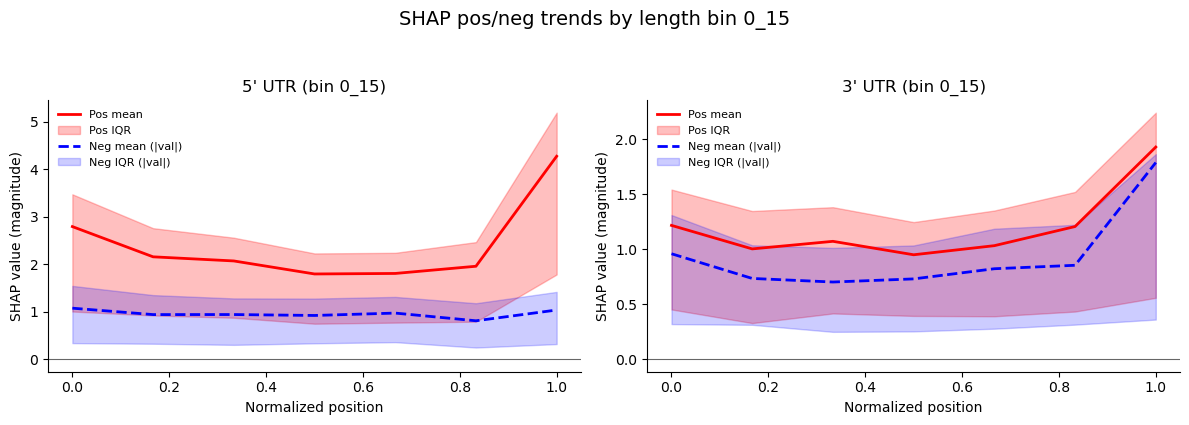

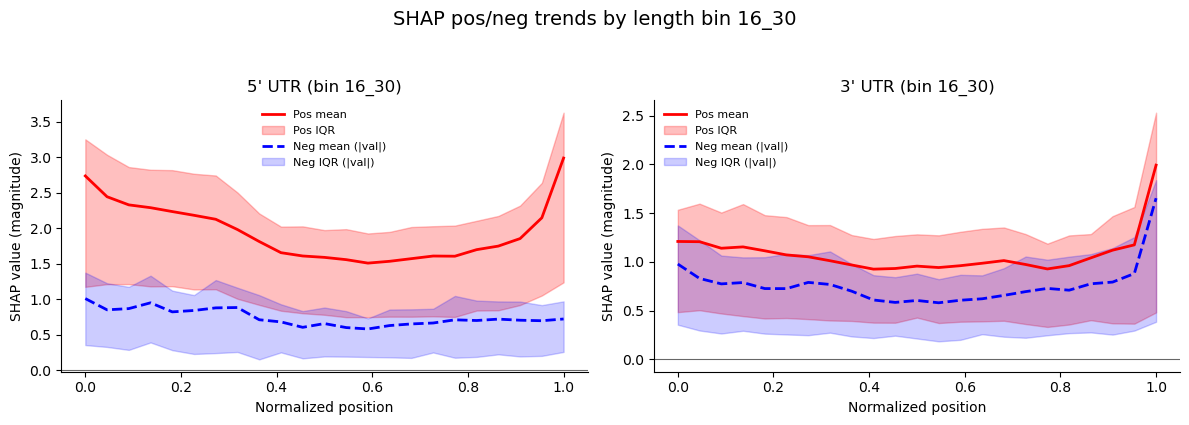

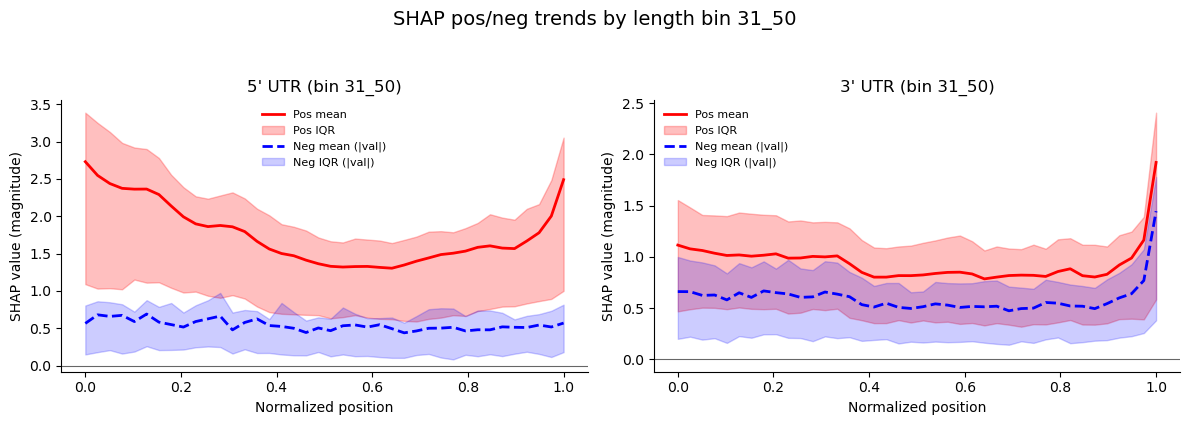

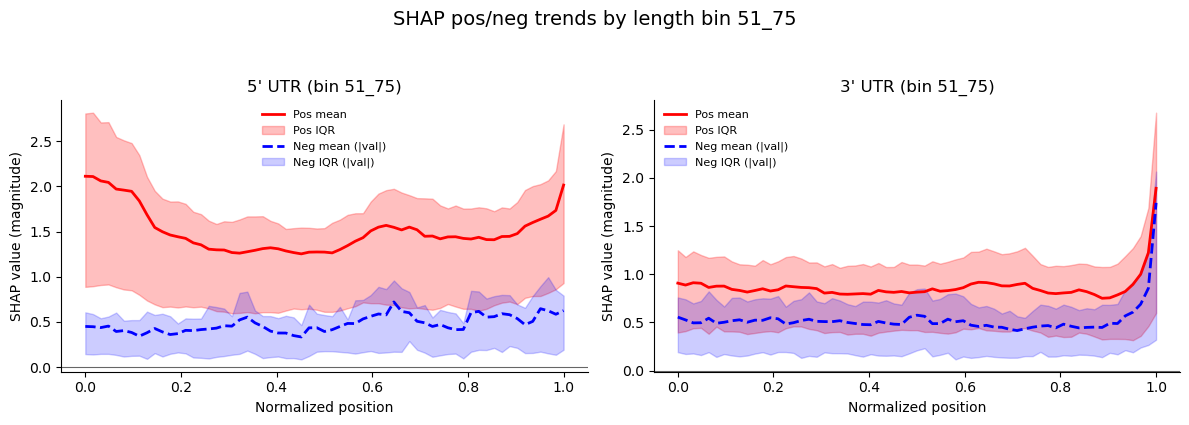

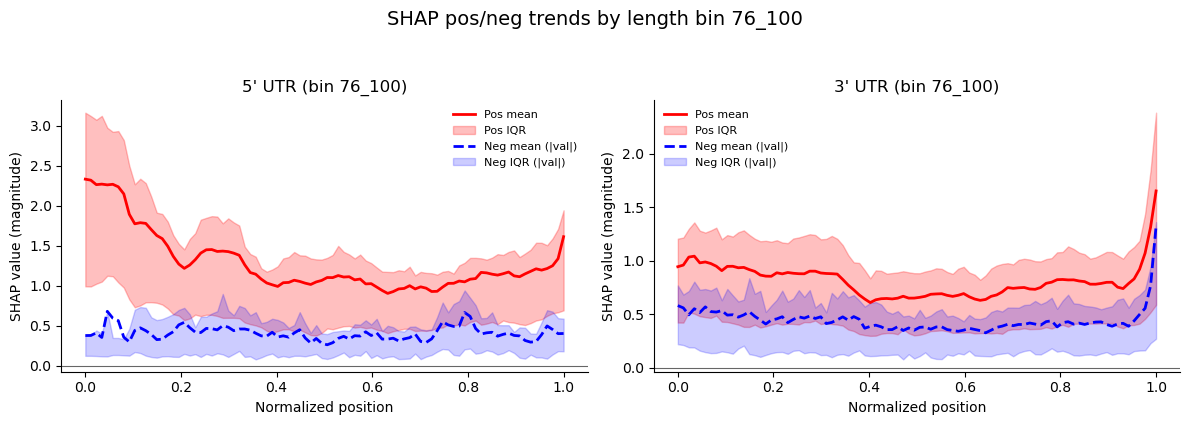

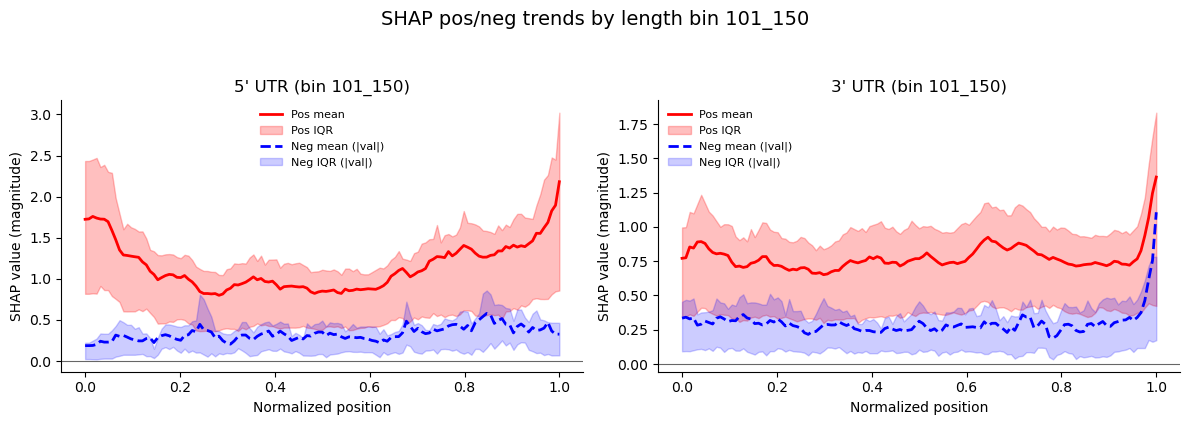

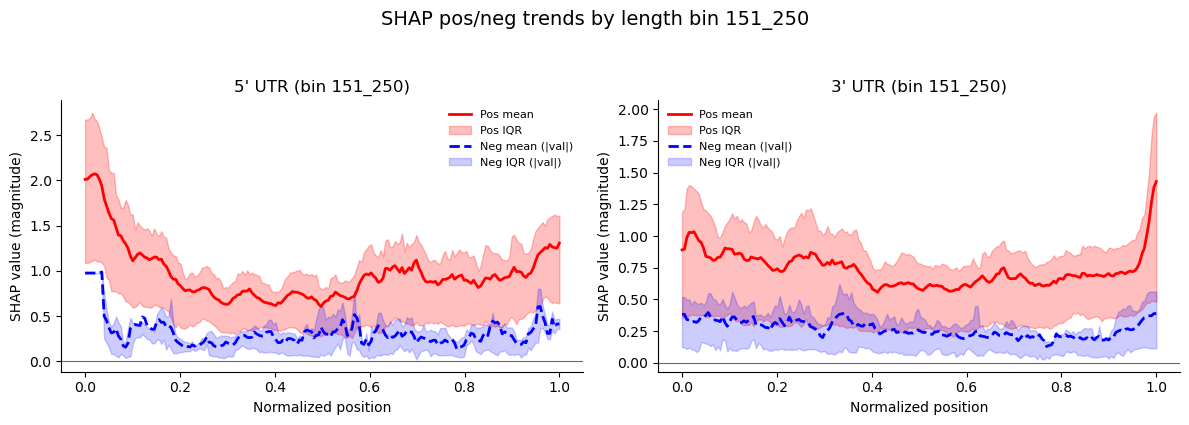

Mean of empty slice
All-NaN slice encountered


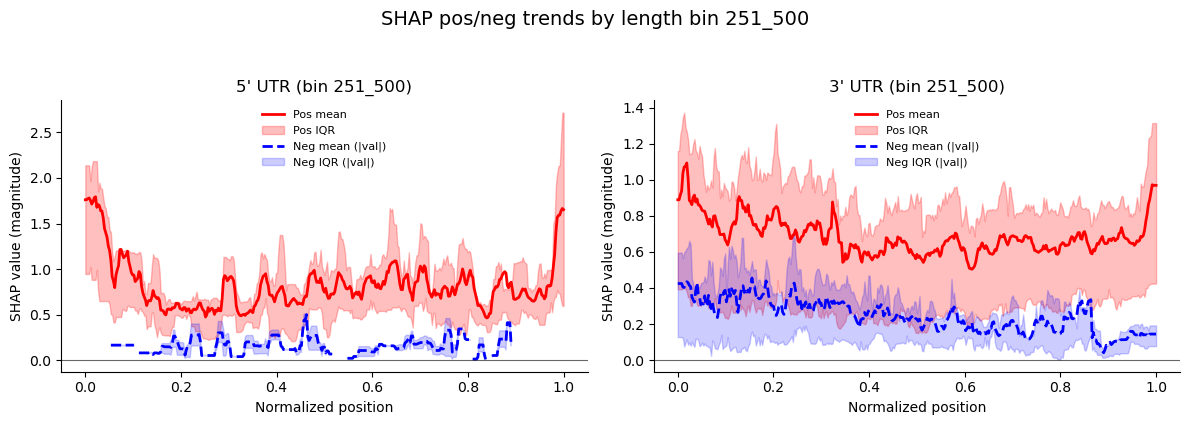

In [89]:
import numpy as np

# Plot average (mean) pos/neg SHAP for 5' and 3' UTR per length group (bins in interp)

import matplotlib.pyplot as plt

# Ensure deterministic ordering of bins by their numeric start
def bin_sort_key(b):
    try:
        return int(b.split('_')[0]), int(b.split('_')[1])
    except:
        return (999999, 999999)

for bin_label in sorted(interp.keys(), key=bin_sort_key):
    bin_data = interp[bin_label]

    pos5_all, neg5_all, pos3_all, neg3_all = [], [], [], []
    for ds in ['dev', 'train', 'test']:
        if bin_data[ds]['pos5'] is not None:
            pos5_all.extend(bin_data[ds]['pos5'])
        if bin_data[ds]['neg5'] is not None:
            neg5_all.extend(bin_data[ds]['neg5'])
        if bin_data[ds]['pos3'] is not None:
            pos3_all.extend(bin_data[ds]['pos3'])
        if bin_data[ds]['neg3'] is not None:
            neg3_all.extend(bin_data[ds]['neg3'])

    # Skip empty bins
    if (len(pos5_all)==0 and len(neg5_all)==0) and (len(pos3_all)==0 and len(neg3_all)==0):
        continue

    # All sequences in a bin were interpolated to target_len = (minLen+maxLen)//2 used when created
    try:
        minLen, maxLen = map(int, bin_label.split('_'))
        target_len = (minLen + maxLen) // 2
    except:
        # Fallback: infer from first available sequence
        for lst in [pos5_all, neg5_all, pos3_all, neg3_all]:
            if lst:
                target_len = len(lst[0])
                break
    x = np.linspace(0, 1, target_len)

    def stack_and_stats(seq_list):
        seq_list = [a for a in seq_list if a is not None and len(a)==target_len]
        if not seq_list:
            return None
        arr = np.vstack(seq_list)
        mean = np.nanmean(arr, axis=0)
        p25 = np.nanpercentile(arr, 25, axis=0)
        p75 = np.nanpercentile(arr, 75, axis=0)
        return dict(mean=mean, p25=p25, p75=p75)

    stats_pos5 = stack_and_stats(pos5_all)
    stats_neg5 = stack_and_stats(neg5_all)
    stats_pos3 = stack_and_stats(pos3_all)
    stats_neg3 = stack_and_stats(neg3_all)

    # Skip if both panels empty
    if stats_pos5 is None and stats_neg5 is None and stats_pos3 is None and stats_neg3 is None:
        continue

    fig, (ax5, ax3) = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

    def plot_panel(ax, stats_pos, stats_neg, title):
        if stats_pos:
            ax.plot(x, stats_pos['mean'], color='red', lw=2, label="Pos mean")
            ax.fill_between(x, stats_pos['p25'], stats_pos['p75'], color='red', alpha=0.25, label="Pos IQR")
        if stats_neg:
            # neg lists already contain |neg| magnitudes -> plot as dashed
            ax.plot(x, stats_neg['mean'], color='blue', lw=2, ls='--', label="Neg mean (|val|)")
            ax.fill_between(x, stats_neg['p25'], stats_neg['p75'], color='blue', alpha=0.20, label="Neg IQR (|val|)")
        ax.axhline(0, color='black', lw=0.8, alpha=0.6)
        ax.set_title(title)
        ax.set_xlabel("Normalized position")
        ax.set_ylabel("SHAP value (magnitude)")
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.legend(frameon=False, fontsize=8)

    plot_panel(ax5, stats_pos5, stats_neg5, f"5' UTR (bin {bin_label})")
    plot_panel(ax3, stats_pos3, stats_neg3, f"3' UTR (bin {bin_label})")

    fig.suptitle(f"SHAP pos/neg trends by length bin {bin_label}", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"figures/SHAP_posneg_lengthbin_{bin_label}.svg", bbox_inches='tight')
    plt.show()

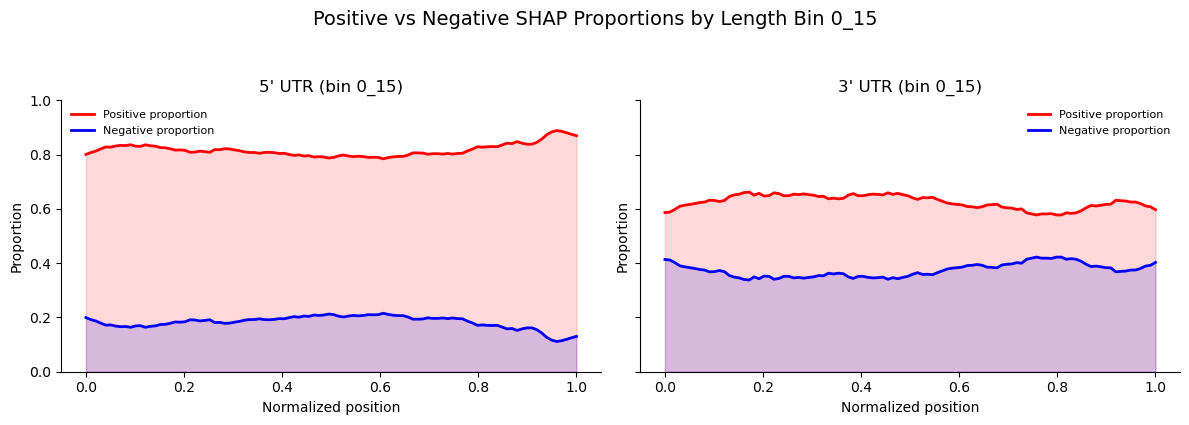

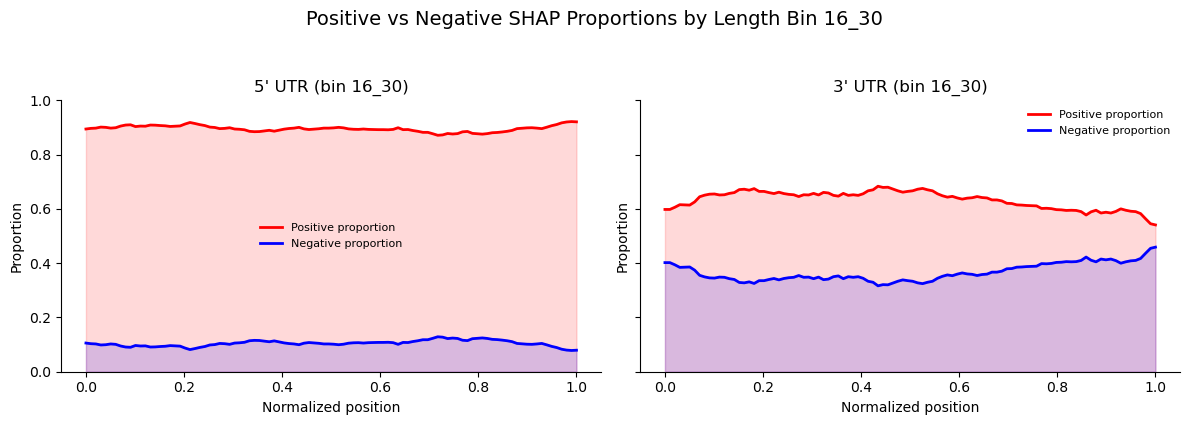

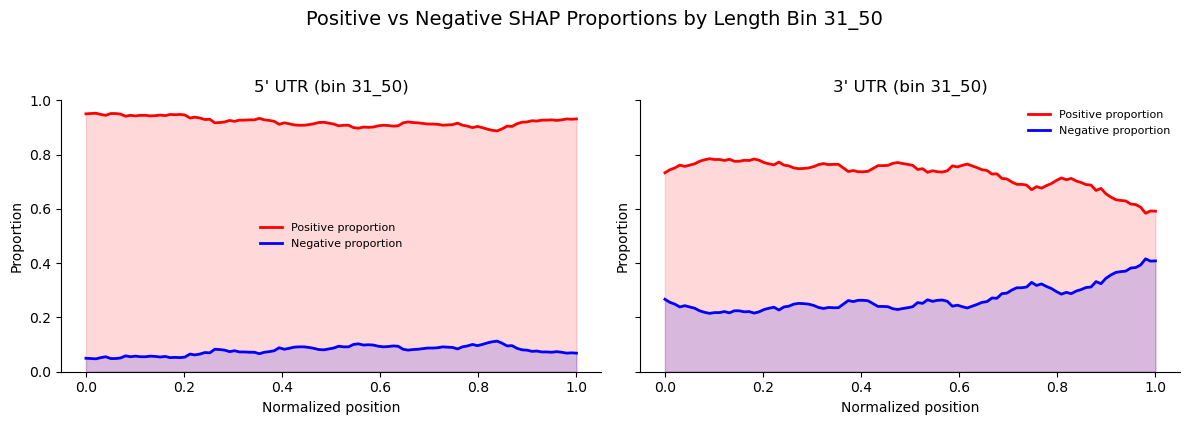

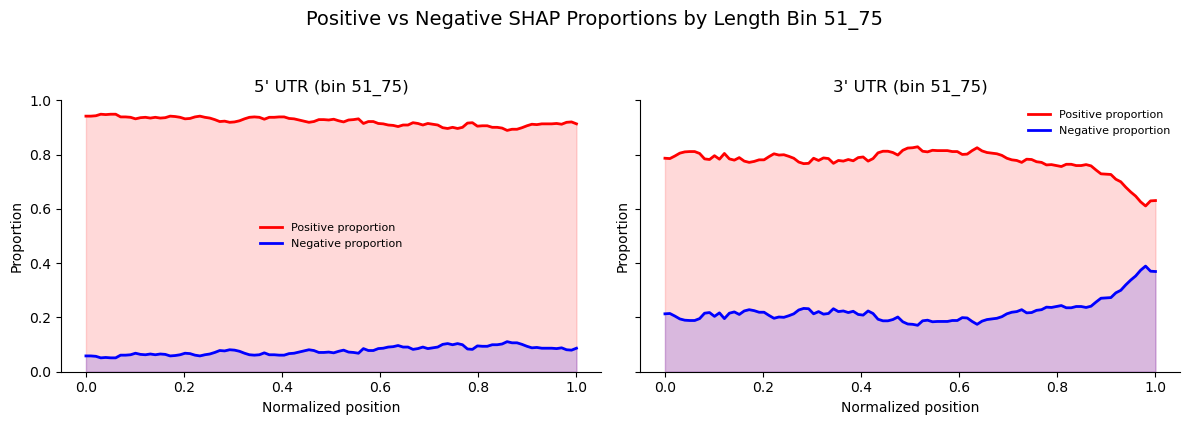

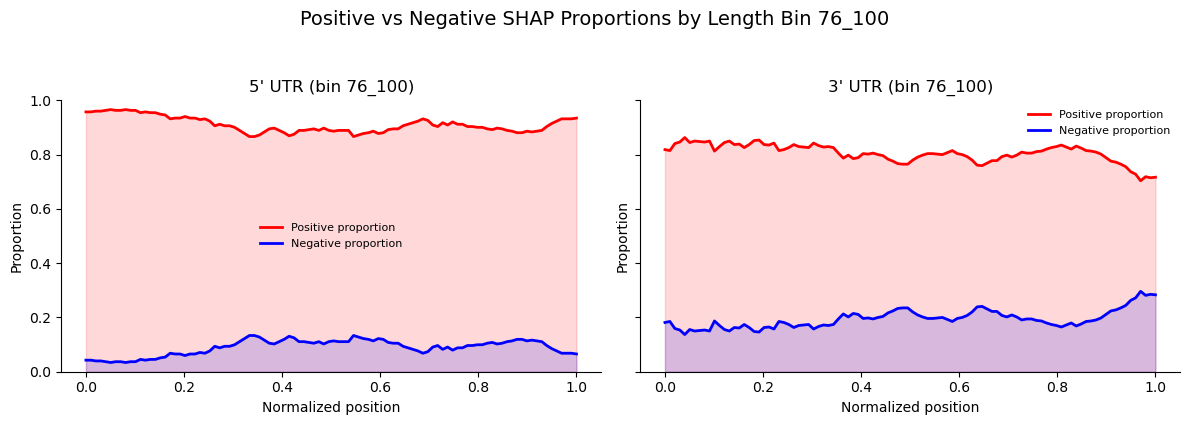

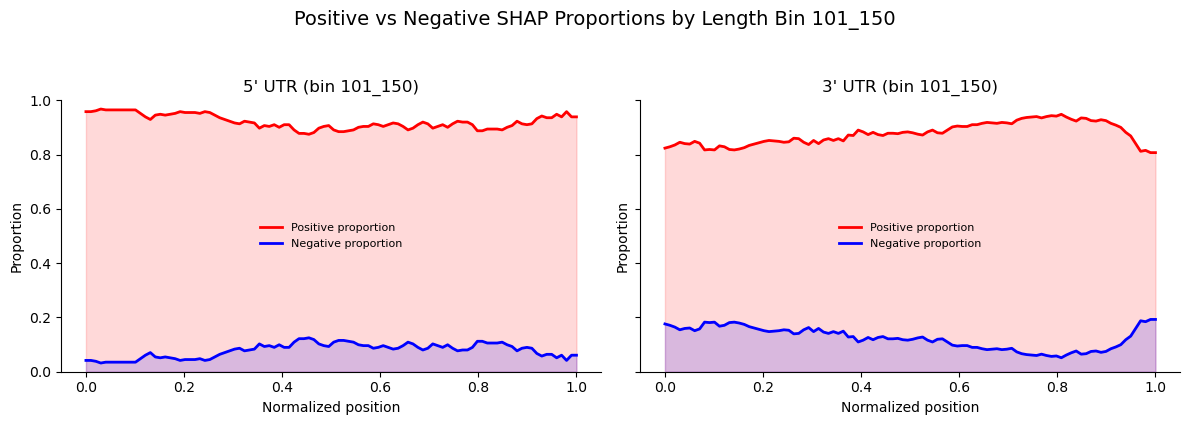

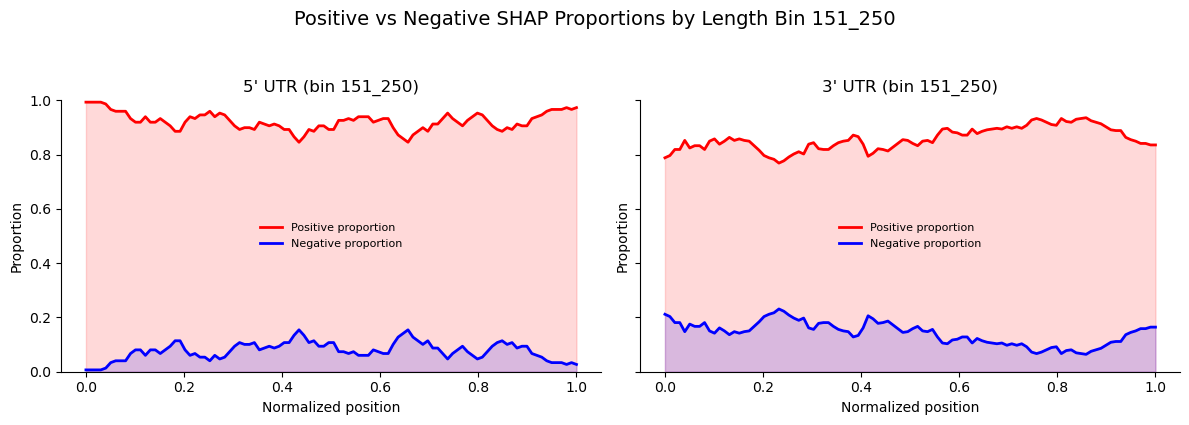

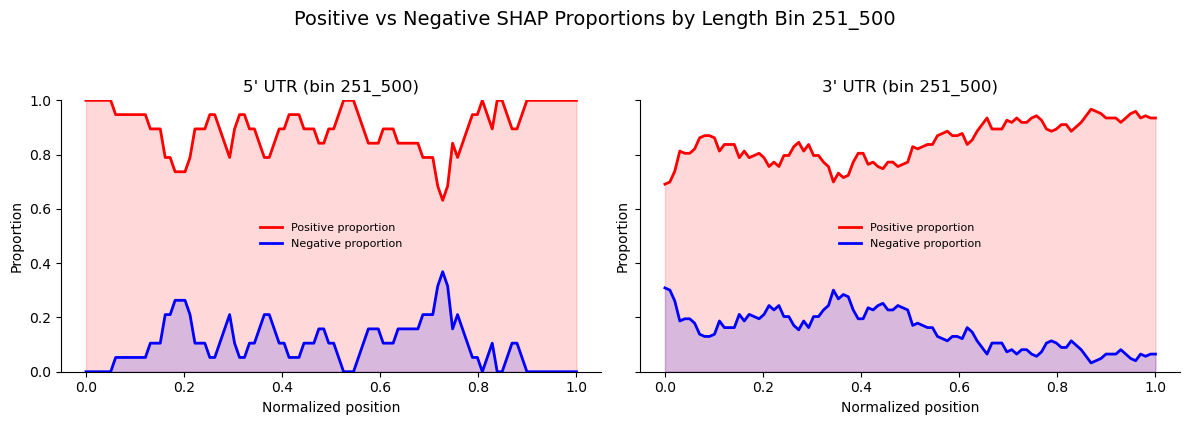

In [85]:
import numpy as np

# Proportion of positive vs negative SHAP values per position for each length bin
# Uses the 'interp' structure created earlier (cell 37)

import matplotlib.pyplot as plt

# Get ordered bin labels
try:
    bin_labels = sorted(interp.keys(), key=bin_sort_key)
except NameError:
    def bin_sort_key(b):
        try:
            return int(b.split('_')[0]), int(b.split('_')[1])
        except:
            return (999999, 999999)
    bin_labels = sorted(interp.keys(), key=bin_sort_key)

for bin_label in bin_labels:
    bin_data = interp[bin_label]

    # Collect sequences across all datasets for this bin
    pos5_all, neg5_all, pos3_all, neg3_all = [], [], [], []
    for ds in ['dev', 'train', 'test']:
        pos5_all.extend(bin_data[ds]['pos5'] or [])
        neg5_all.extend(bin_data[ds]['neg5'] or [])
        pos3_all.extend(bin_data[ds]['pos3'] or [])
        neg3_all.extend(bin_data[ds]['neg3'] or [])

    # Skip if empty
    if (len(pos5_all) + len(neg5_all) == 0) and (len(pos3_all) + len(neg3_all) == 0):
        continue

    def proportions(pos_list, neg_list):
        if len(pos_list) == 0 and len(neg_list) == 0:
            return None, None, None
        # Determine length (all arrays interpolated to same length)
        L = None
        for lst in (pos_list, neg_list):
            if lst:
                L = len(lst[0])
                break
        if L is None:
            return None, None, None
        # Stack with shape (n_seq, L); treat presence (non-nan) as indicator
        pos_present = []
        for a in pos_list:
            if len(a) == L:
                pos_present.append(~np.isnan(a))
        neg_present = []
        for a in neg_list:
            if len(a) == L:
                neg_present.append(~np.isnan(a))
        if len(pos_present) == 0 and len(neg_present) == 0:
            return None, None, None
        pos_present = np.vstack(pos_present) if pos_present else np.zeros((0, L), dtype=bool)
        neg_present = np.vstack(neg_present) if neg_present else np.zeros((0, L), dtype=bool)
        count_pos = pos_present.sum(axis=0)
        count_neg = neg_present.sum(axis=0)
        denom = count_pos + count_neg  # sequences with non-zero (pos or neg) SHAP at position
        with np.errstate(divide='ignore', invalid='ignore'):
            prop_pos = np.where(denom > 0, count_pos / denom, np.nan)
            prop_neg = np.where(denom > 0, count_neg / denom, np.nan)
        return prop_pos, prop_neg, np.linspace(0, 1, L)

    prop_pos5, prop_neg5, x5p = proportions(pos5_all, neg5_all)
    prop_pos3, prop_neg3, x3p = proportions(pos3_all, neg3_all)

    # Skip if nothing to plot
    if prop_pos5 is None and prop_pos3 is None:
        continue

    fig, (ax5, ax3) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    def plot_panel(ax, x, ppos, pneg, title):
        if x is None:
            ax.text(0.5, 0.5, "No data", ha='center', va='center')
        else:
            ax.plot(x, ppos, color='red', lw=2, label='Positive proportion')
            ax.plot(x, pneg, color='blue', lw=2, label='Negative proportion')
            ax.fill_between(x, ppos, 0, color='red', alpha=0.15)
            ax.fill_between(x, pneg, 0, color='blue', alpha=0.15)
            ax.set_ylim(0, 1)
            ax.set_xlabel("Normalized position")
            ax.set_ylabel("Proportion")
            ax.legend(frameon=False, fontsize=8)
        ax.set_title(title)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plot_panel(ax5, x5p, prop_pos5, prop_neg5, f"5' UTR (bin {bin_label})")
    plot_panel(ax3, x3p, prop_pos3, prop_neg3, f"3' UTR (bin {bin_label})")

    fig.suptitle(f"Positive vs Negative SHAP Proportions by Length Bin {bin_label}", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"figures/SHAP_posneg_proportions_lengthbin_{bin_label}.svg", bbox_inches='tight')
    plt.show()

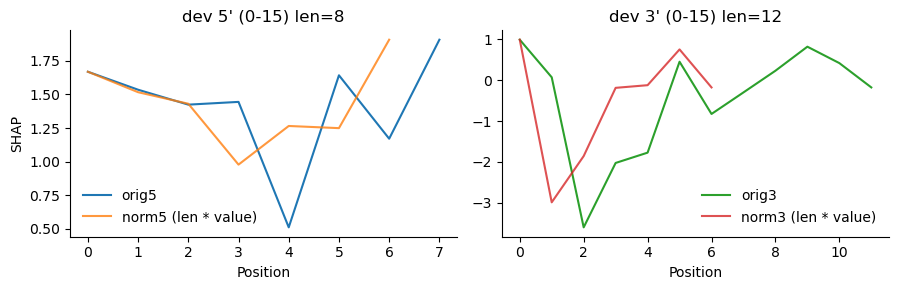

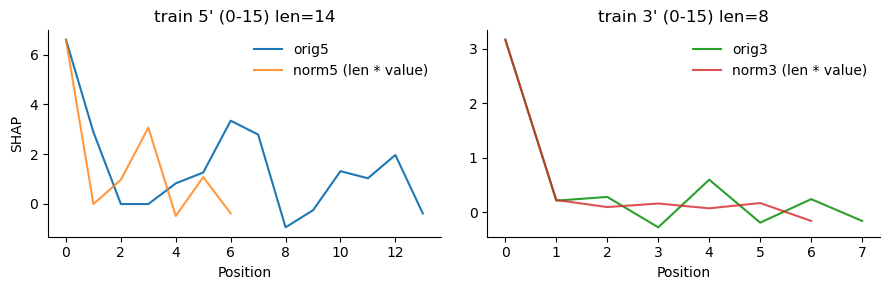

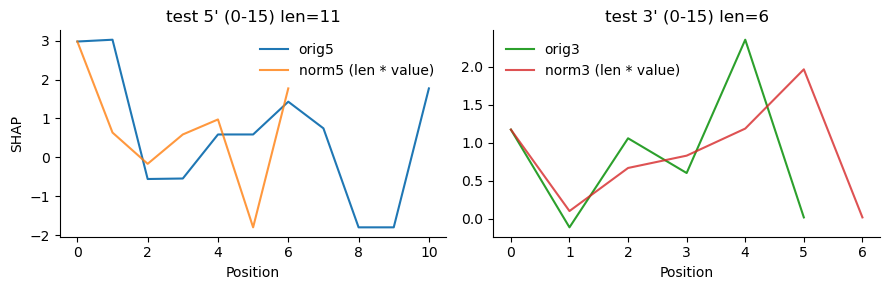

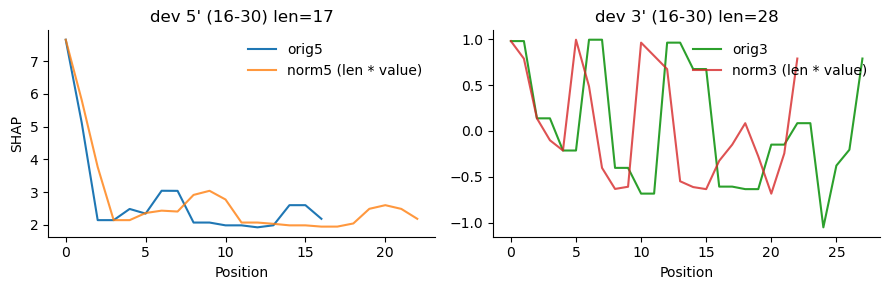

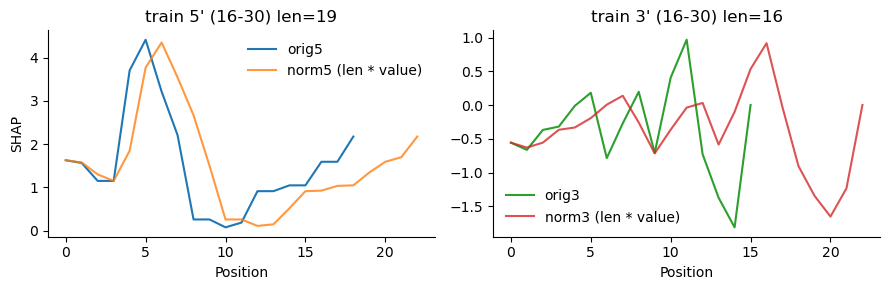

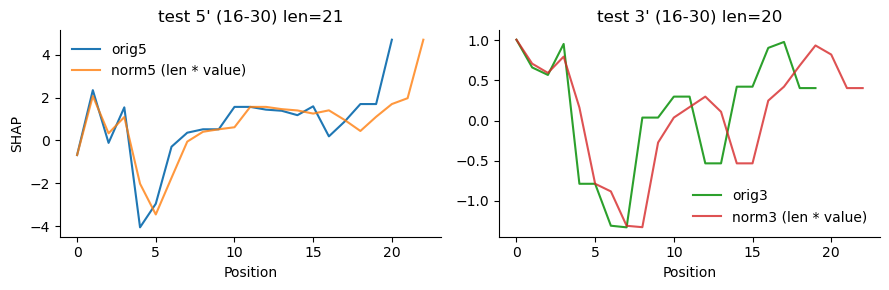

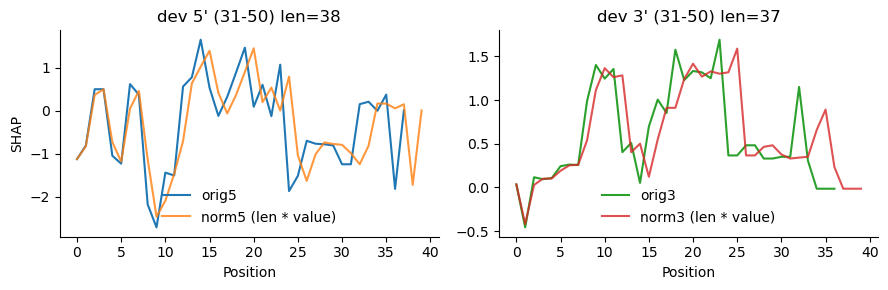

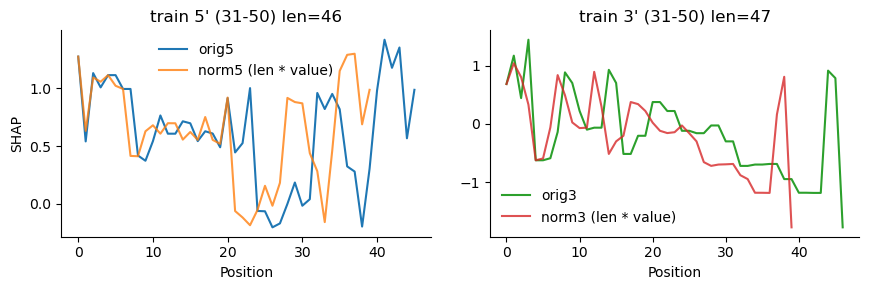

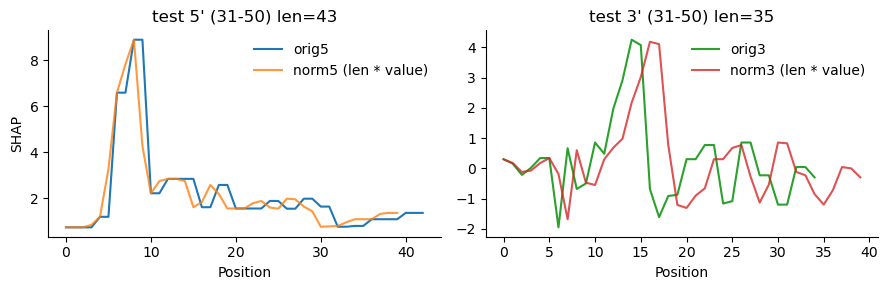

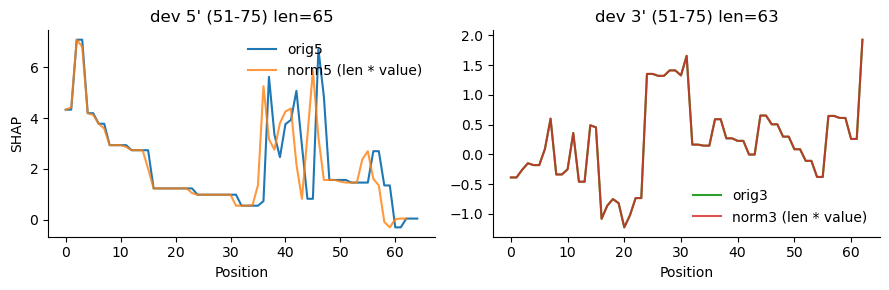

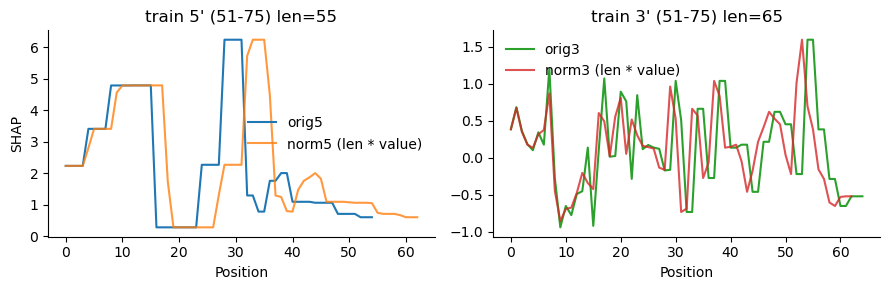

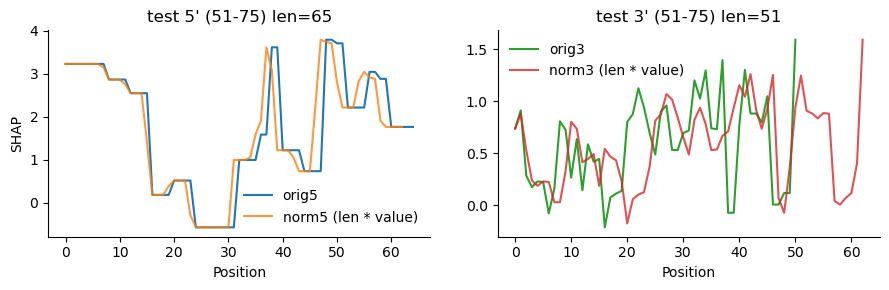

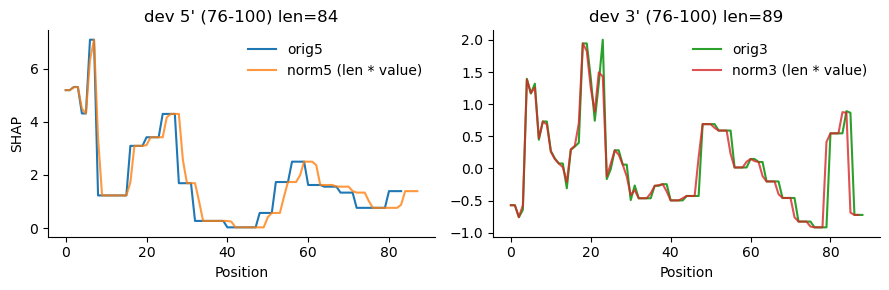

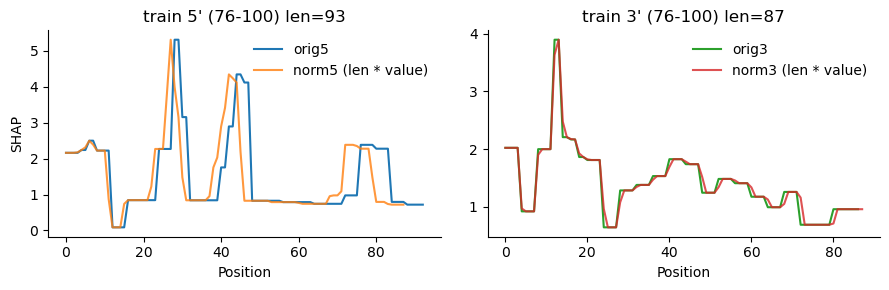

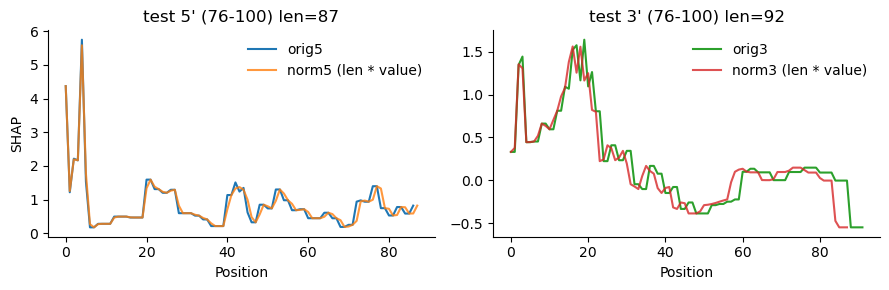

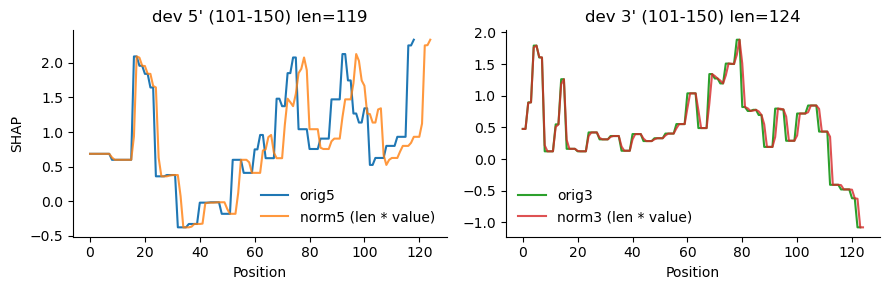

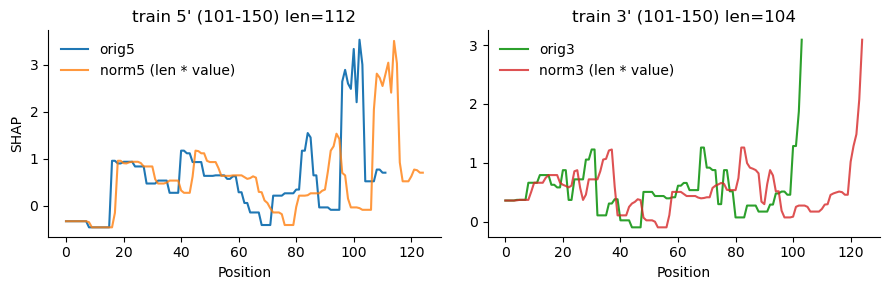

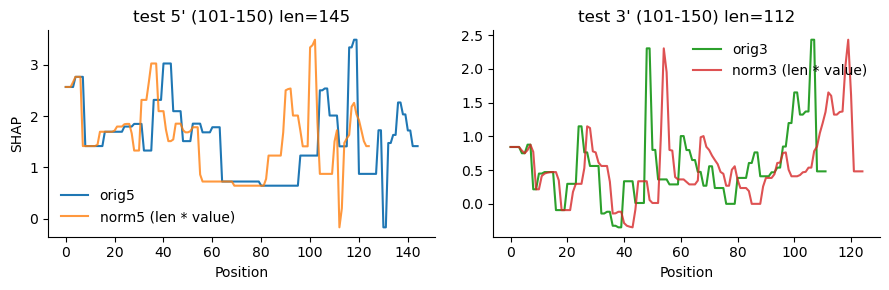

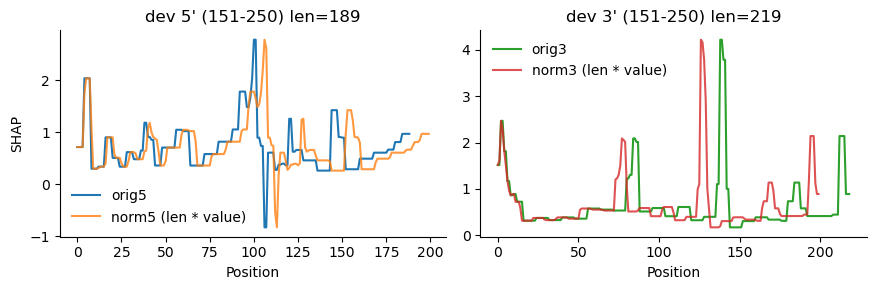

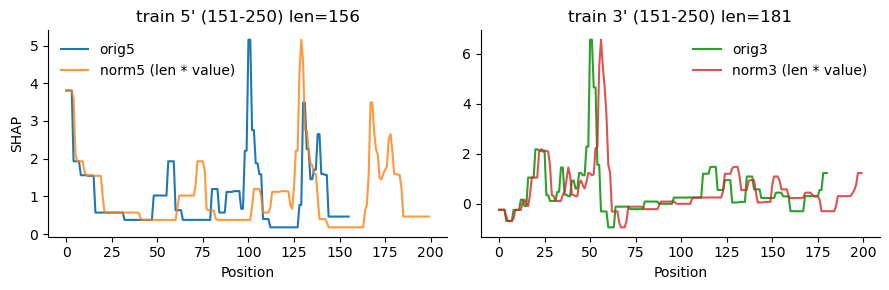

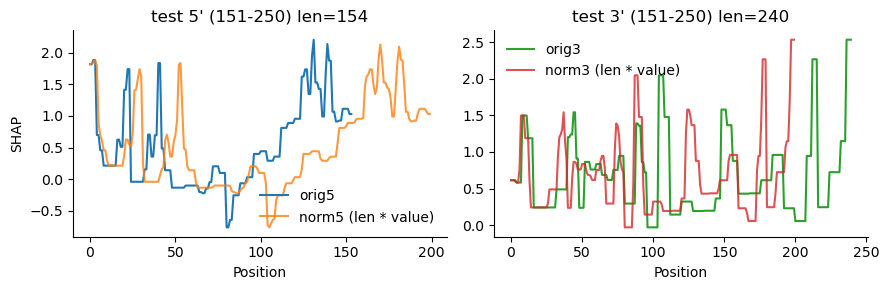

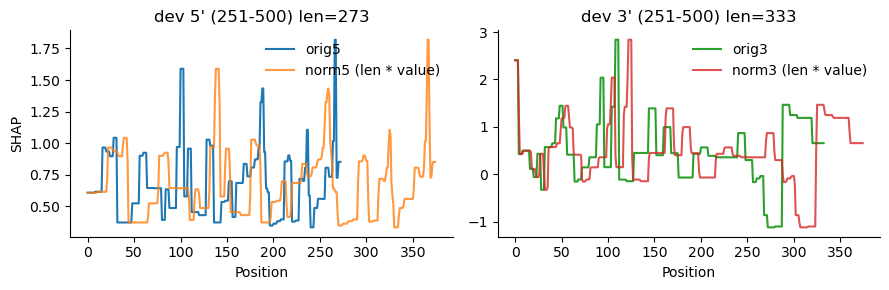

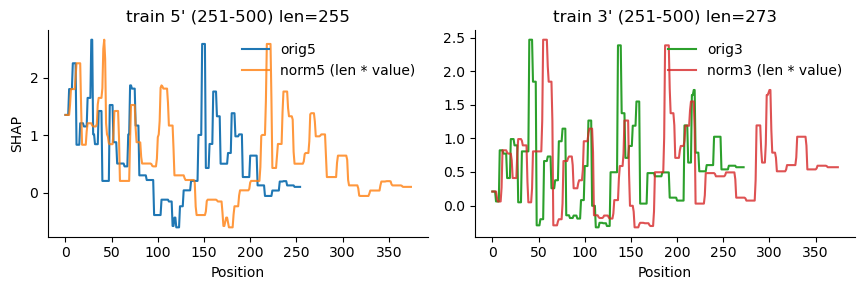

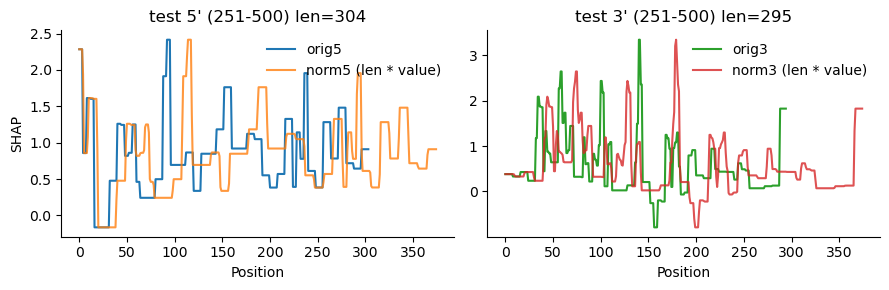

In [96]:

def aggregate_pos_neg(sequences, tgt_len):
    pos_list, neg_list = [], []
    x_new = np.linspace(0, 1, tgt_len)
    for tmp in sequences:
        if len(tmp) < 2:
            continue
        seq = tmp.copy()
        x_old = np.linspace(0, 1, len(seq))
        seq_new = interp1d(x_old, seq, kind="linear")(x_new)
        break  # store magnitudes

    return tmp, seq_new


interp = {}
for minLen, maxLen in [(0,15),(16,30), (31,50),(51,75),(76,100),(101,150),(151,250),(251,500)]:
    target_len = (minLen + maxLen) // 2
    interp[f"{minLen}_{maxLen}"] = {'dev': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}, 'train': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}, 'test': {'pos5': None, 'neg5':None, 'pos3': None, 'neg3':None}}
    for group in ['dev', 'train', 'test']:
        # Prepare (do not mutate originals)
        trunc5 = [seq for seq in seqs5[group] if minLen <= len(seq) <= maxLen]
        trunc3 = [seq for seq in seqs3[group] if minLen <= len(seq) <= maxLen]

        # Aggregate
        orig5, norm5 = aggregate_pos_neg(trunc5, target_len)
        orig3, norm3 = aggregate_pos_neg(trunc3, target_len)
        # Plot first (example) sequence original vs length-scaled for 5' and 3'
        if isinstance(orig5, np.ndarray) and isinstance(norm5, np.ndarray):
            fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(9, 3))
            ax_left.plot(orig5, label="orig5", color='tab:blue')
            ax_left.plot(norm5, label="norm5 (len * value)", color='tab:orange', alpha=0.8)
            ax_left.set_title(f"{group} 5' ({minLen}-{maxLen}) len={len(orig5)}")
            ax_left.set_xlabel("Position")
            ax_left.set_ylabel("SHAP")
            ax_left.legend(frameon=False)
            ax_left.spines['top'].set_visible(False)
            ax_left.spines['right'].set_visible(False)

            if isinstance(orig3, np.ndarray) and isinstance(norm3, np.ndarray):
                ax_right.plot(orig3, label="orig3", color='tab:green')
                ax_right.plot(norm3, label="norm3 (len * value)", color='tab:red', alpha=0.8)
                ax_right.set_title(f"{group} 3' ({minLen}-{maxLen}) len={len(orig3)}")
                ax_right.set_xlabel("Position")
                ax_right.legend(frameon=False)
                ax_right.spines['top'].set_visible(False)
                ax_right.spines['right'].set_visible(False)
            else:
                ax_right.set_visible(False)

            plt.tight_layout()
            plt.show()

5' UTR length: 1059
3' UTR length: 198


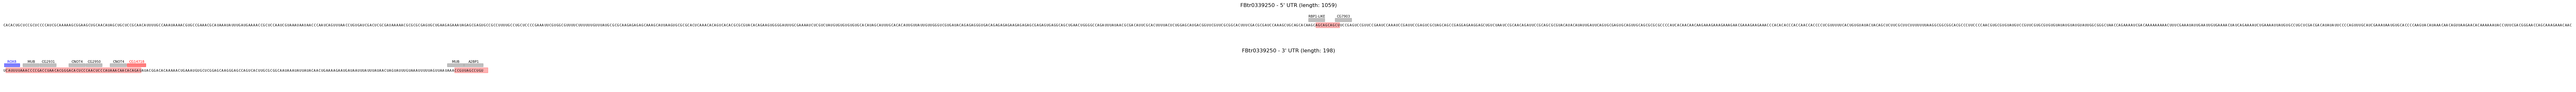


Summary for FBtr0339250:
Positive motif regions: 3
Negative motif regions: 0
RBP hits in 5' UTR: 2
RBP hits in 3' UTR: 9
5' UTR length: 238
3' UTR length: 87


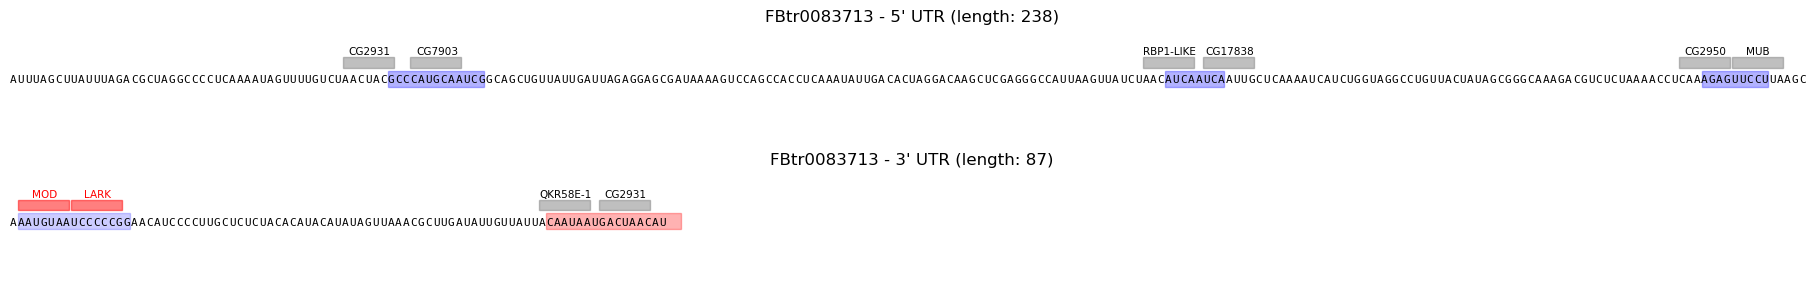


Summary for FBtr0083713:
Positive motif regions: 1
Negative motif regions: 4
RBP hits in 5' UTR: 6
RBP hits in 3' UTR: 4
5' UTR length: 1012
3' UTR length: 263


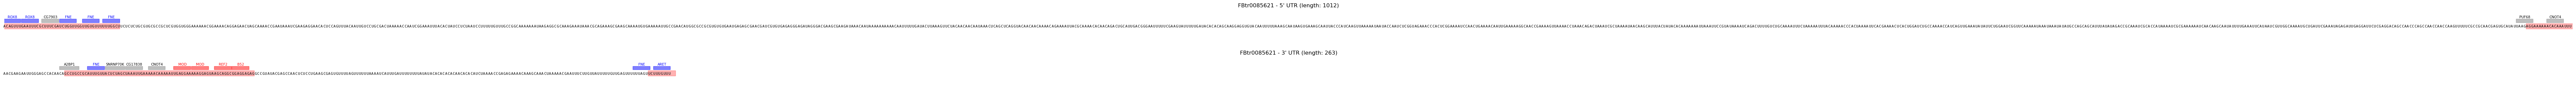


Summary for FBtr0085621:
Positive motif regions: 4
Negative motif regions: 0
RBP hits in 5' UTR: 8
RBP hits in 3' UTR: 11
5' UTR length: 158
3' UTR length: 145


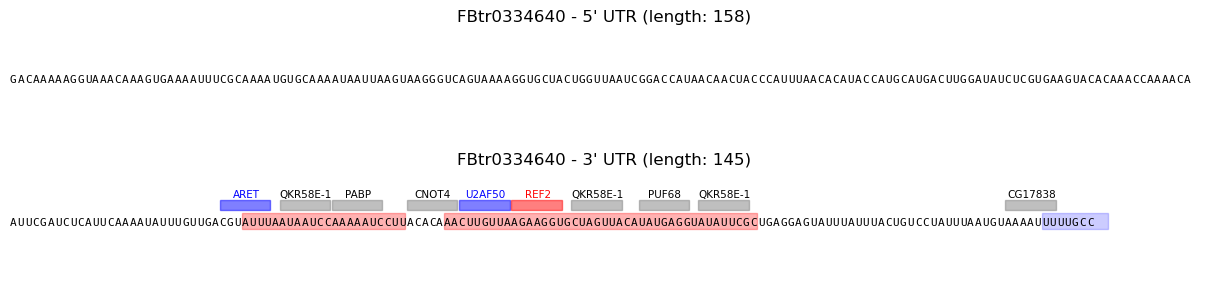


Summary for FBtr0334640:
Positive motif regions: 2
Negative motif regions: 1
RBP hits in 5' UTR: 0
RBP hits in 3' UTR: 10
5' UTR length: 95
3' UTR length: 292


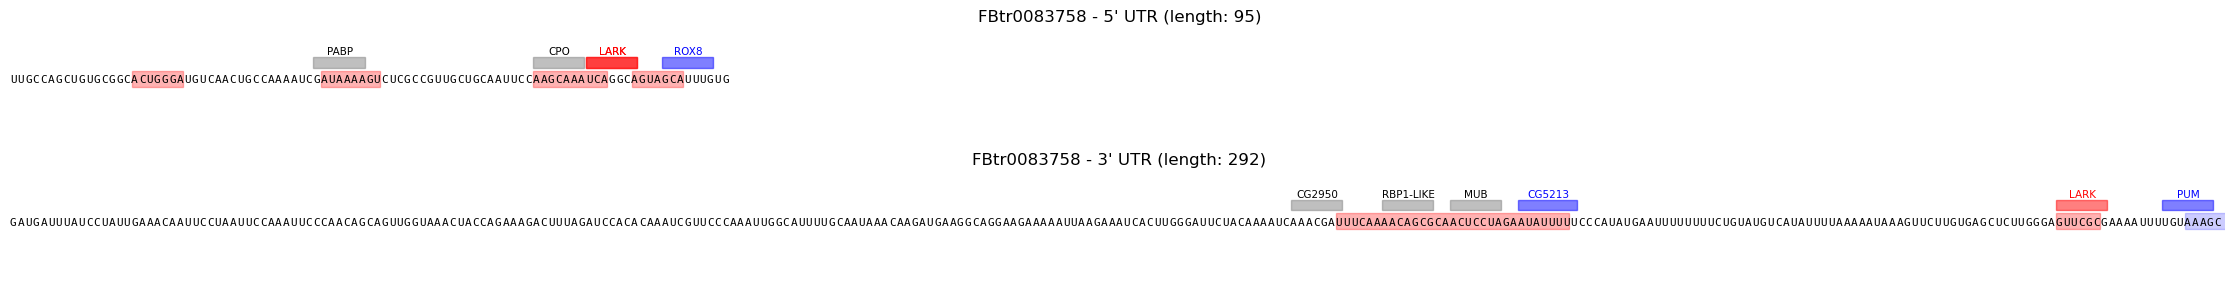


Summary for FBtr0083758:
Positive motif regions: 6
Negative motif regions: 1
RBP hits in 5' UTR: 5
RBP hits in 3' UTR: 6
5' UTR length: 106
3' UTR length: 239


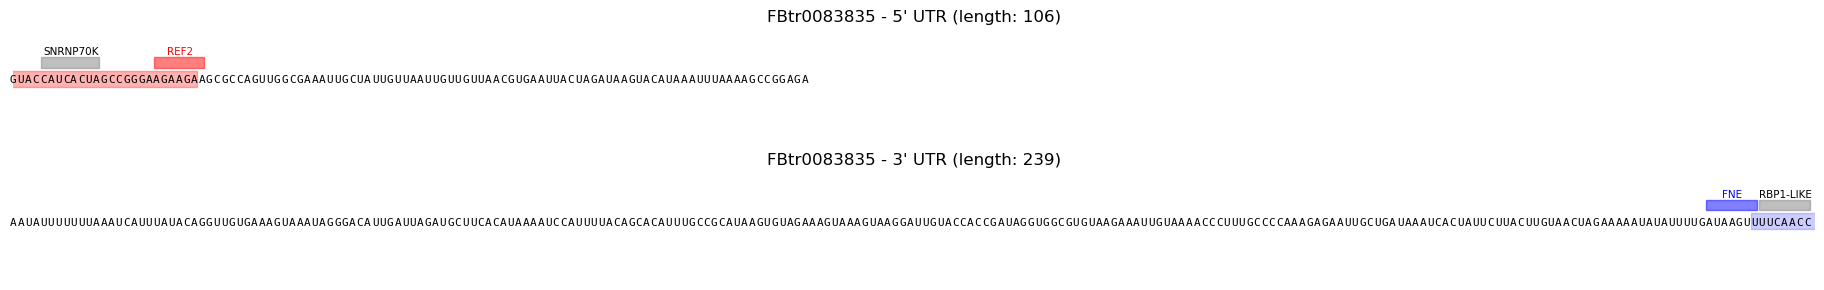


Summary for FBtr0083835:
Positive motif regions: 1
Negative motif regions: 1
RBP hits in 5' UTR: 2
RBP hits in 3' UTR: 2
5' UTR length: 159
3' UTR length: 398


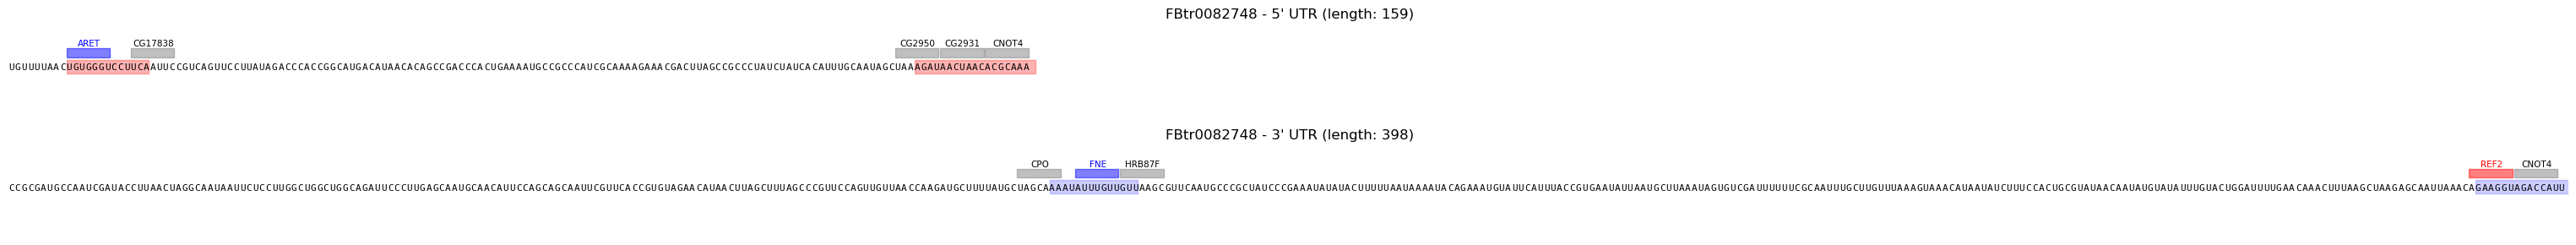


Summary for FBtr0082748:
Positive motif regions: 2
Negative motif regions: 2
RBP hits in 5' UTR: 5
RBP hits in 3' UTR: 5
5' UTR length: 140
3' UTR length: 270


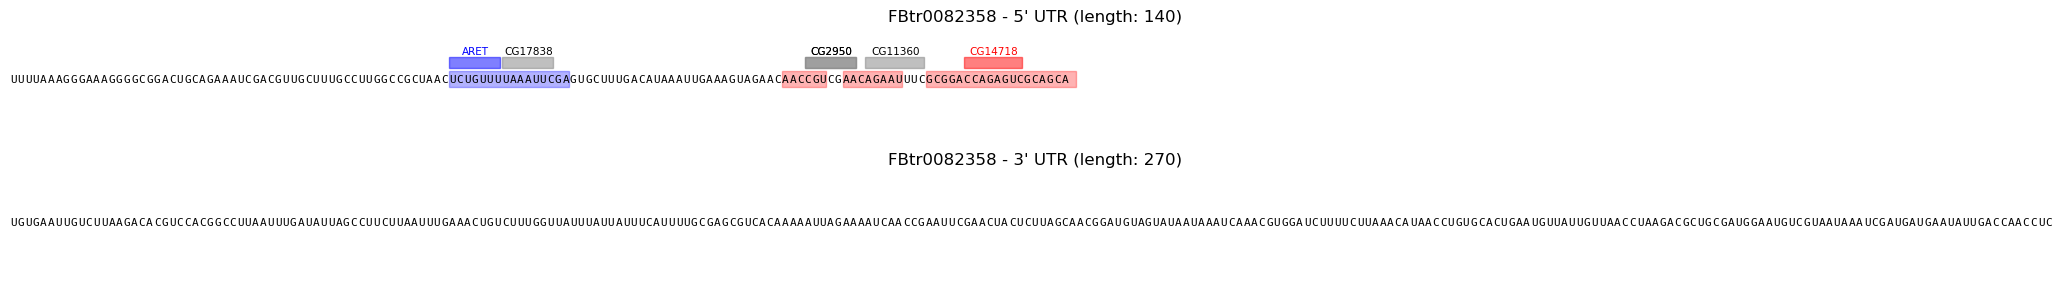


Summary for FBtr0082358:
Positive motif regions: 3
Negative motif regions: 1
RBP hits in 5' UTR: 6
RBP hits in 3' UTR: 0
5' UTR length: 154
3' UTR length: 803


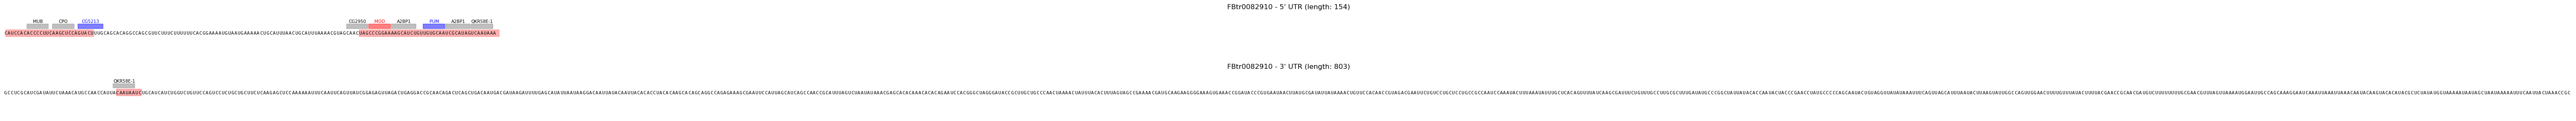


Summary for FBtr0082910:
Positive motif regions: 3
Negative motif regions: 0
RBP hits in 5' UTR: 9
RBP hits in 3' UTR: 1
5' UTR length: 74
3' UTR length: 142


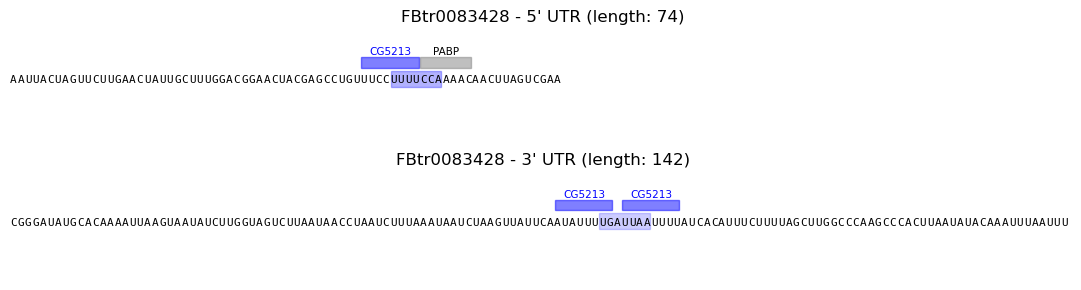


Summary for FBtr0083428:
Positive motif regions: 0
Negative motif regions: 2
RBP hits in 5' UTR: 2
RBP hits in 3' UTR: 2
5' UTR length: 116
3' UTR length: 195


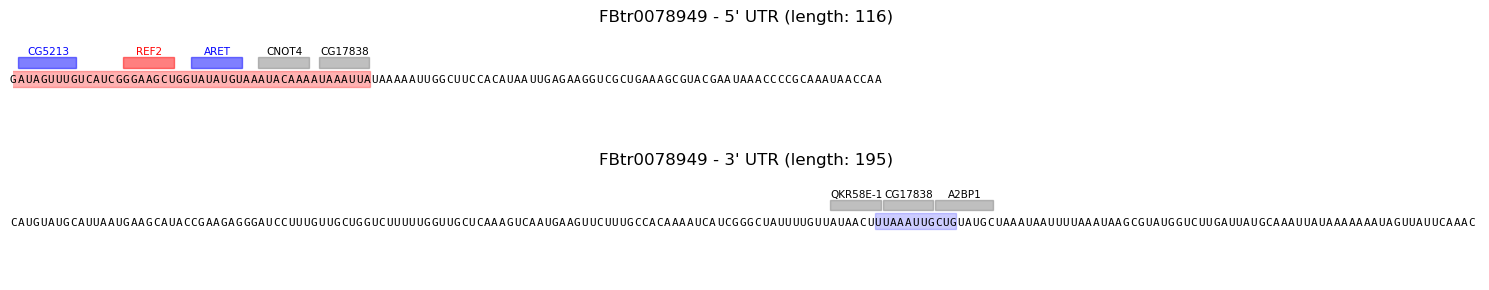


Summary for FBtr0078949:
Positive motif regions: 1
Negative motif regions: 1
RBP hits in 5' UTR: 5
RBP hits in 3' UTR: 3
5' UTR length: 70
3' UTR length: 471


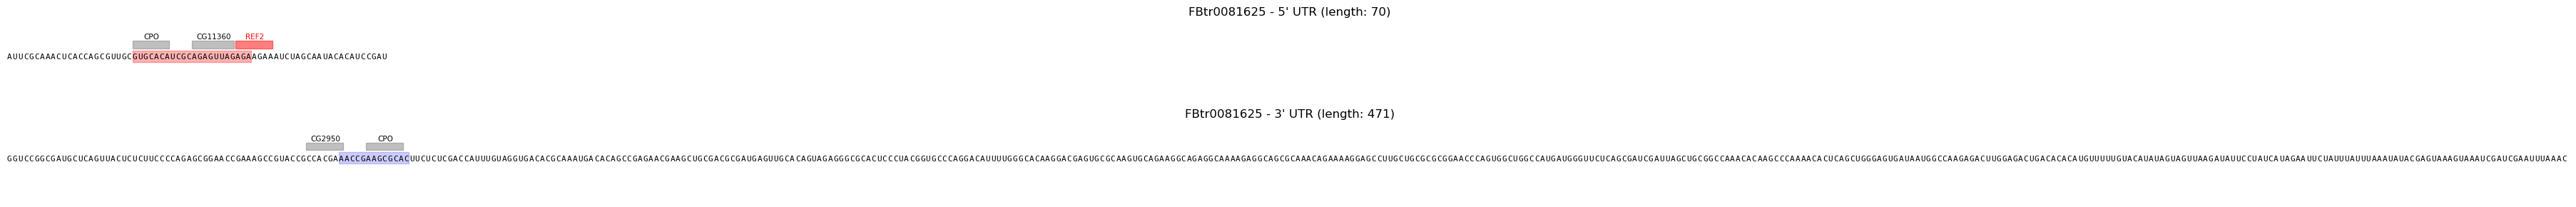


Summary for FBtr0081625:
Positive motif regions: 1
Negative motif regions: 1
RBP hits in 5' UTR: 3
RBP hits in 3' UTR: 2
5' UTR length: 251
3' UTR length: 778


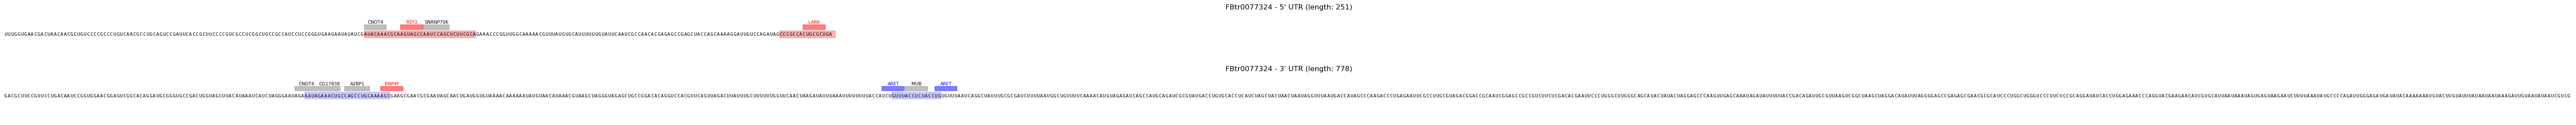


Summary for FBtr0077324:
Positive motif regions: 2
Negative motif regions: 2
RBP hits in 5' UTR: 4
RBP hits in 3' UTR: 7
5' UTR length: 183
3' UTR length: 815


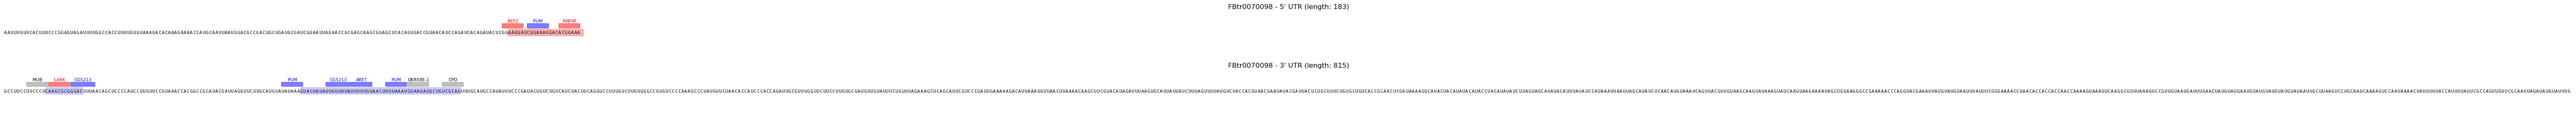


Summary for FBtr0070098:
Positive motif regions: 1
Negative motif regions: 2
RBP hits in 5' UTR: 3
RBP hits in 3' UTR: 9


In [100]:
# Read the file, skipping the first two lines that start with #
import pandas as pd
import os
from Bio import SeqIO

try:
    df = pd.read_csv('output/mast_out/dev_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python')
except:
    os.chdir('../..')
    df = pd.read_csv('output/mast_out/dev_mast_results.txt', sep='\s+', skiprows=2, skipfooter=1, engine='python')
df.columns = ['sequence_name', 'strand', 'id', 'alt_id', 'hit_start','hit_end','score','p_value']

motifPos = pd.read_csv('output/motifs/dev/positive/motif_positions.txt', sep='\t')
motifNeg = pd.read_csv('output/motifs/dev/negative/motif_positions.txt', sep='\t')

from Bio import SeqIO
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib

def draw_sequence(ax, seq, y=0.007, fontsize=8):
    for i, ch in enumerate(seq):
        ax.text(i, y, ch, fontproperties='monospace', fontsize=fontsize, ha='center', va='center')

def span_from_1based(start, end):
    # convert 1-based inclusive [start,end] to 0-based start and width in bases
    start0 = int(start) - 1
    width = int(end) - int(start) + 1
    return start0, width
#matplotlib.use('Agg')  # Use same backend for both display and save
#plt.rcParams['figure.dpi'] = 300  # Set consistent DPI

def filter_rbp_hits(pMotifs, nMotifs, rbp5, rbp3):
    mergedMotifs = pd.concat([pMotifs, nMotifs], ignore_index=True)
    filt5 = pd.DataFrame(columns=rbp5.columns)
    filt3 = pd.DataFrame(columns=rbp3.columns)
    for _, motif in mergedMotifs.iterrows():
        if motif['start'] <= motif['sepStart']:  # 5' UTR region
            if motif['trID']+'_5utr' in rbp5['sequence_name'].values:
                tmp = rbp5[rbp5['sequence_name'] == motif['trID']+'_5utr']
                for t in tmp.iterrows():
                    if (t[1]['hit_start'] >= motif['start'] and t[1]['hit_start'] <= motif['end']) or (t[1]['hit_end'] > motif['start'] and t[1]['hit_end'] <= motif['end']):
                        filt5 = pd.concat([filt5, pd.DataFrame([t[1]])], ignore_index=True)
        else:  # 3' UTR region
            if motif['trID']+'_3utr' in rbp3['sequence_name'].values:
                tmp = rbp3[rbp3['sequence_name'] == motif['trID']+'_3utr']
                for t in tmp.iterrows():
                    if (t[1]['hit_start'] >= (motif['start'] - motif['sepEnd']) and t[1]['hit_start'] <= (motif['end'] - motif['sepEnd'])) or (t[1]['hit_end'] > (motif['start'] - motif['sepEnd']) and t[1]['hit_end'] <= (motif['end'] - motif['sepEnd'])):
                        filt3 = pd.concat([filt3, pd.DataFrame([t[1]])], ignore_index=True)
    return filt5, filt3

# Find the sequence for FBtr0073819
for target_trID in ['FBtr0339250', 'FBtr0083713','FBtr0085621',   'FBtr0334640','FBtr0083758','FBtr0083835',   'FBtr0082748','FBtr0082358','FBtr0082910','FBtr0083428','FBtr0078949','FBtr0081625','FBtr0077324','FBtr0070098']:
    target_seq = None
    
    # Read the dev.fasta file to find the target sequence
    with open('output/data/decay/dev.fasta', 'r') as fasta_file:
        for seq_record in SeqIO.parse(fasta_file, 'fasta'):
            tr_id = seq_record.description.split()[1]
            if tr_id == target_trID:
                target_seq = str(seq_record.seq)
                break
            
    if target_seq is None:
        print(f"Sequence {target_trID} not found in dev.fasta")
    else:
        # Split into 5' and 3' UTRs based on comma
        comma_pos = target_seq.index(',')
        utr5_seq = target_seq[:comma_pos]
        utr3_seq = target_seq[comma_pos+1:]
        
        print(f"5' UTR length: {len(utr5_seq)}")
        print(f"3' UTR length: {len(utr3_seq)}")
        
        # Get positive motif positions for this trID
        pos_motifs = motifPos[motifPos['trID'] == target_trID]
        
        # Get negative motif positions for this trID
        neg_motifs = motifNeg[motifNeg['trID'] == target_trID]
        
        # Get RBP motif hits from df for this trID
        rbp_hits_5utr = df[df['sequence_name'] == f'{target_trID}_5utr']
        rbp_hits_3utr = df[df['sequence_name'] == f'{target_trID}_3utr']
        # Filter RBP hits to only those overlapping with positive/negative motifs
        rbp_hits_5utr, rbp_hits_3utr = filter_rbp_hits(pos_motifs, neg_motifs, rbp_hits_5utr, rbp_hits_3utr)
        
        # Define motif groups
        positive_motifs = ['RNP4F','REF2','B52','CG33714','MOD','LARK','CG14718']
        negative_motifs = ['FNE','U2AF50','ROX8','ARET','CG5213','PUM']
        
        # Create the visualization
        xmax = max(len(utr5_seq), len(utr3_seq))  # Extend x-axis to accommodate motifs
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(0.0769*xmax, 3))
        rectHeight = 0.03
        rectY_SHAP = -0.005
        alphaSHAP = 0.3
        rectY_Motif = 0.03
        ymin = -0.1
        ymax = 0.1
        xminMod = 0#-1
        xmaxMod = 0#31
        rbpHeight = 0.02
        rbpLabelHeight = 0.05
        widthMod = 0.4
        motifStartMod = 0.4
        
        # Plot 5' UTR
        #ax1.text(0, 0, utr5_seq, fontfamily='monospace', fontsize=8)
        draw_sequence(ax1, utr5_seq, fontsize=8)
        ax1.set_xlim(xminMod, xmax + xmaxMod)
        ax1.set_ylim(ymin, ymax)
        ax1.set_title(f"{target_trID} - 5' UTR (length: {len(utr5_seq)})")
        ax1.yaxis.set_visible(False)  # Hide y-axis for better visualization
        ax1.axis('off')
    
    
        # Add positive motif boxes for 5' UTR
        for _, motif in pos_motifs.iterrows():
            if motif['start'] <= motif['sepStart']:  # 5' UTR region
                start_pos = motif['start'] - motifStartMod
                end_pos = motif['end']
                width = end_pos - start_pos + widthMod
                rect = patches.Rectangle((start_pos, rectY_SHAP), width, rectHeight, 
                                       linewidth=1, edgecolor='red', facecolor='red', alpha=alphaSHAP)
                ax1.add_patch(rect)
                #ax1.axvspan(start_pos, end_pos, color='red', alpha=0.5)
        
        # Add negative motif boxes for 5' UTR
        for _, motif in neg_motifs.iterrows():
            if motif['start'] <= motif['sepStart']:  # 5' UTR region
                start_pos = motif['start'] - motifStartMod
                end_pos = motif['end']
                width = end_pos - start_pos + widthMod
                rect = patches.Rectangle((start_pos, rectY_SHAP), width, rectHeight, 
                                       linewidth=1, edgecolor='blue', facecolor='blue', alpha=alphaSHAP)
                ax1.add_patch(rect)
                #ax1.axvspan(start_pos, end_pos, color='blue', alpha=0.5)
        
        # Add RBP motif labels above 5' UTR sequence
        for _, rbp in rbp_hits_5utr.iterrows():
            color = 'red' if rbp['alt_id'] in positive_motifs else 'blue' if rbp['alt_id'] in negative_motifs else 'black'
            mid_pos = (rbp['hit_start']-1.4-motifStartMod + rbp['hit_end']) / 2
            ax1.text(mid_pos, rbpLabelHeight, rbp['alt_id'], ha='center', va='bottom', 
                    fontsize=7.5, color=color)#, rotation=45)
        
        # Plot 3' UTR
        #ax2.text(0, 0, utr3_seq, fontfamily='monospace', fontsize=8)
        draw_sequence(ax2, utr3_seq, fontsize=8)
        ax2.set_xlim(xminMod, xmax + xmaxMod)
        ax2.set_ylim(ymin, ymax)
        ax2.set_title(f"{target_trID} - 3' UTR (length: {len(utr3_seq)})")
        ax2.yaxis.set_visible(False)  # Hide y-axis for better visualization
        ax2.axis('off')
        
        # Add positive motif boxes for 3' UTR
        for _, motif in pos_motifs.iterrows():
            if motif['start'] > motif['sepStart']:  # 3' UTR region
                start_pos = motif['start'] - motif['sepEnd'] - motifStartMod
                end_pos = motif['end'] - motif['sepEnd']
                width = end_pos - start_pos + widthMod
                rect = patches.Rectangle((start_pos, rectY_SHAP), width, rectHeight, 
                                       linewidth=1, edgecolor='red', facecolor='red', alpha=alphaSHAP)
                ax2.add_patch(rect)
                #ax2.axvspan(start_pos, end_pos, color='red', alpha=0.5)
        
        # Add negative motif boxes for 3' UTR
        for _, motif in neg_motifs.iterrows():
            if motif['start'] > motif['sepStart']:  # 3' UTR region
                start_pos = motif['start'] - motif['sepEnd'] - motifStartMod
                end_pos = motif['end'] - motif['sepEnd']
                width = end_pos - start_pos + widthMod
                rect = patches.Rectangle((start_pos, rectY_SHAP), width, rectHeight, 
                                       linewidth=1, edgecolor='blue', facecolor='blue', alpha=0.2)
                ax2.add_patch(rect)
                #ax2.axvspan(start_pos, end_pos, color='blue', alpha=0.5)
    
        
        # Add RBP motif labels above 3' UTR sequence
        for _, rbp in rbp_hits_3utr.iterrows():
            color = 'red' if rbp['alt_id'] in positive_motifs else 'blue' if rbp['alt_id'] in negative_motifs else 'black'
            mid_pos = (rbp['hit_start']-1.4-motifStartMod + rbp['hit_end']) / 2
            ax2.text(mid_pos, rbpLabelHeight, rbp['alt_id'], ha='center', va='bottom', 
                    fontsize=7.5, color=color)#, rotation=45)
    
        # Add RBP motif spans
        for _, rbp in rbp_hits_5utr.iterrows():
            color = 'red' if rbp['alt_id'] in positive_motifs else 'blue' if rbp['alt_id'] in negative_motifs else 'gray'
            #ax1.axvspan(rbp['hit_start']-1, rbp['hit_end']-0.25, color=color, alpha=0.2, linewidth=0)
            ax1.add_patch(patches.Rectangle((rbp['hit_start']-1-motifStartMod, rectY_Motif), rbp['hit_end']-rbp['hit_start']+0.75, rbpHeight, 
                                       linewidth=1, edgecolor=color, facecolor=color, alpha=0.5))
    
        for _, rbp in rbp_hits_3utr.iterrows():
            color = 'red' if rbp['alt_id'] in positive_motifs else 'blue' if rbp['alt_id'] in negative_motifs else 'gray'
            #ax2.axvspan(rbp['hit_start']-1, rbp['hit_end']-0.25, color=color, alpha=0.2, linewidth=0)
            ax2.add_patch(patches.Rectangle((rbp['hit_start']-1-motifStartMod, rectY_Motif), rbp['hit_end']-rbp['hit_start']+0.75, rbpHeight, 
                                       linewidth=1, edgecolor=color, facecolor=color, alpha=0.5))
        
        plt.tight_layout()
        #plt.savefig(f'figures/{target_trID}_motif_visualization.svg', dpi=300)
        plt.show()
        # Print summary
        print(f"\nSummary for {target_trID}:")
        print(f"Positive motif regions: {len(pos_motifs)}")
        print(f"Negative motif regions: {len(neg_motifs)}")
        print(f"RBP hits in 5' UTR: {len(rbp_hits_5utr)}")
        print(f"RBP hits in 3' UTR: {len(rbp_hits_3utr)}") 